In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from google.colab import files

Punto 1

In [ ]:
#os.chdir(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\All_paises.xlsx')
#print(os.listdir())  # Muestra todos los archivos en el directorio actual

In [2]:
# Cargo las bases de datos
#df_ALL=pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\All_paises.xlsx')
uploaded = files.upload()  # Elegís el archivo All_paises.xlsx
df_ALL= pd.read_excel(next(iter(uploaded.keys())))


Saving All_paises (1).xlsx to All_paises (1) (1).xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [ ]:
Dftogpt=df_ALL.head(5)

In [ ]:
print(Dftogpt.columns.tolist())


In [ ]:
Dftogpt.to_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\Dftogpt.xlsx', index=False)

Analizamos que variables nos interesan

In [3]:
import pandas as pd
import numpy as np

# ============================================================
# 1️⃣ Cargar base y definir países sudamericanos
# ============================================================
#df = pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\All_paises.xlsx')
df = df_ALL

# Códigos numéricos de países sudamericanos
paises_sudamerica_cod = [32, 68, 76, 152, 170, 218, 600, 604, 858, 862]

# Detectar la columna del país
col_pais = [c for c in df.columns if "IDENPA" in c.upper()][0]

# Filtrar solo países de Sudamérica
df = df[df[col_pais].isin(paises_sudamerica_cod)]

print(f"✅ Filtrados {len(df)} casos correspondientes a Sudamérica")

# ============================================================
# 2️⃣ Seleccionar variables (por código base)
# ============================================================
codigos = [
    # Políticas
    "P12STGBS.A", "P12STGBS.B", "P13ST", "P15STGBS", "P16ST",
    "P17ST", "P18ST.A", "P18ST.B", "P18ST.C", "P18ST.D", "P19ST", "P15STGBS",
    # Económicas
    "P6STGBS", "P7STGBS", "P9STGBS", "S5", "S6",
    # Sociales
    "P2ST", "P10STGBS", "P26ST", "P27ST", "P51ST", "P55ST",
    # Demográficas
    "S2", "S4", "S7", "S10", "S11", "S17", "SEXO", "S18.A"
]

# Buscar columnas reales que contengan los códigos base
cols_reales = [col for col in df.columns if any(code in col for code in codigos)]
print(f"Columnas seleccionadas ({len(cols_reales)}):")
for c in cols_reales:
    print(" -", c)

# ============================================================
# 3️⃣ Recodificación binaria
# ============================================================
def binarizar_serie(serie):
    if pd.api.types.is_numeric_dtype(serie):
        med = serie.median(skipna=True)
        return np.where(serie >= med, 1, 0)
    else:
        positivos = ["Sí", "De acuerdo", "Positiva", "Alta", "Buena", "Satisfecho"]
        return serie.apply(lambda x: 1 if isinstance(x, str) and any(p in x for p in positivos) else 0)

df_bin = df[[col_pais] + cols_reales].copy()

for c in cols_reales:
    df_bin[c] = binarizar_serie(df_bin[c])

# ============================================================
# 4️⃣ Limpieza final
# ============================================================
df_final = df_bin.dropna().reset_index(drop=True)
print("Shape final:", df_final.shape)
df_final.head()


✅ Filtrados 12014 casos correspondientes a Sudamérica
Columnas seleccionadas (51):
 - SEXO: Sexo
 - P2ST: Imagen de progreso del país
 - P6STGBS: Situación económica actual del país
 - P7STGBS: Situación económica actual del país comparada con hace doce meses
 - P9STGBS: Como será su situación económica y la de su familia dentro de doce meses
 - P10STGBS: Se puede confiar en la mayoría de las personas o uno nunca es lo suficientemente cuidadoso en el trato con los demás
 - P12STGBS.A: Satisfacción con la democracia
 - P12STGBS.B: Satisfacción con el funcionamiento de la economía en (país)
 - P13ST: {PAÍS} gobernado por unos cuantos grupos poderosos en su propio beneficio o para el bien de todo el pueblo
 - P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente
 - P16ST: Autoubicación en escala Izquierda-Derecha
 - P17ST: Cuán justa es la distribución del ingreso en {PAÍS}
 - P18ST.A: Acuerdo/Desacuerdo: La democracia puede tener problemas pero es el mejor sistema de

,IDENPA: País,SEXO: Sexo,P2ST: Imagen de progreso del país,P6STGBS: Situación económica actual del país,P7STGBS: Situación económica actual del país comparada con hace doce meses,P9STGBS: Como será su situación económica y la de su familia dentro de doce meses,P10STGBS: Se puede confiar en la mayoría de las personas o uno nunca es lo suficientemente cuidadoso en el trato con los demás,P12STGBS.A: Satisfacción con la democracia,P12STGBS.B: Satisfacción con el funcionamiento de la economía en (país),P13ST: {PAÍS} gobernado por unos cuantos grupos poderosos en su propio beneficio o para el bien de todo el pueblo,...,S20I: Bienes: Agua potable,S20J: Bienes: Conexión a Internet en el hogar,S20K: Bienes: Calefacción/aire acondicionado,S21A: Edad de finalización de estudios - Jefe de familia,S21B: Nivel de estudios alcanzado - Jefe de familia,S22A: Estado ocupacional del jefe de familia,S22B: Situación ocupacional del jefe de familia anteriormente,S23: Tipo de trabajo que realiza el jefe de familia,S24: Apreciación nivel socioeconómico (realizado por el encuestador),S25: Apreciación de la condición de la entrevista
0,32,1,1,1,1,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,1
1,32,1,1,1,0,1,1,0,1,1,...,1,1,0,1,1,1,1,1,1,1
2,32,0,1,1,1,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,1
3,32,0,1,1,1,1,1,0,1,1,...,1,1,0,1,1,1,1,1,0,1
4,32,1,1,1,1,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,1


In [4]:
import pandas as pd
import numpy as np

# ============================================================
# 1️⃣ Cargar y filtrar Sudamérica
# ============================================================
#df = pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\All_paises.xlsx')

paises_sudamerica_cod = [32, 68, 76, 152, 170, 218, 600, 604, 858, 862]
col_pais = [c for c in df.columns if "IDENPA" in c.upper()][0]
df = df[df[col_pais].isin(paises_sudamerica_cod)]

print(f"✅ Filtrados {len(df)} casos de Sudamérica")

# ============================================================
# 2️⃣ Seleccionar variables (SIN variables de jefe de familia ni encuestador)
# ============================================================
codigos = [
    # Políticas
    "P12STGBS.A", "P12STGBS.B", "P13ST", "P15STGBS", "P16ST",
    "P17ST", "P18ST.A", "P18ST.B", "P18ST.C", "P18ST.D", "P19ST",
    # Económicas
    "P6STGBS", "P7STGBS", "P9STGBS", "S5", "S6",
    # Sociales
    "P2ST", "P10STGBS", "P26ST", "P27ST", "P51ST", "P55ST",
    # Demográficas del ENTREVISTADO solamente
    "S2", "S4", "S11", "EDAD", "SEXO", "S18.A"
]

# Variables a EXCLUIR explícitamente
variables_excluir = [
    "S21A", "S21B",  # Jefe de familia - educación
    "S22A", "S22B",  # Jefe de familia - ocupación
    "S23",           # Tipo trabajo jefe familia
    "S24",           # Apreciación encuestador - nivel socioeconómico
    "S25",           # Apreciación encuestador - condición entrevista
    "REEDAD",        # Edad recodificada (redundante con EDAD)
    "S10"            # Edad fin estudios (ya acordamos borrarla)
]

# Buscar columnas reales
cols_reales = [col for col in df.columns
               if any(code in col for code in codigos)
               and not any(excl in col for excl in variables_excluir)]

print(f"\n📋 Columnas seleccionadas ({len(cols_reales)}):")
for c in sorted(cols_reales):
    print(f" - {c}")

# ============================================================
# 3️⃣ Limpieza de valores especiales
# ============================================================
def limpiar_valores_especiales(serie):
    valores_invalidos = [-1, -3, -5, 96, 97, 98, 99]
    return serie.replace(valores_invalidos, np.nan)

# ============================================================
# 4️⃣ PROCESAMIENTO
# ============================================================
print("\n" + "="*80)
print("⚙️ PROCESANDO VARIABLES...")
print("="*80)

df_procesado = df[[col_pais]].copy()

for col in cols_reales:
    if col not in df.columns:
        continue

    serie = limpiar_valores_especiales(df[col])

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # EDAD: Mantener continua
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    if col == "EDAD":
        df_procesado["EDAD"] = serie
        print(f"✅ {col}: Mantenida continua")

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # P19ST: Escala democracia 1-10
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    elif "P19ST" in col:
        df_procesado["DEMOCRACIA_escala"] = serie
        print(f"✅ {col}: Mantenida como escala 1-10")

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # ORDINALES POSITIVO/NEGATIVO: 1-2 = 1, 3-4 = 0
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    elif "P12STGBS.A" in col:
        df_procesado["SAT_DEMOCRACIA_bin"] = np.where(serie <= 2, 1, 0)
        print(f"✅ {col}: 1-2=Satisfecho(1), 3-4=Insatisfecho(0)")

    elif "P12STGBS.B" in col:
        df_procesado["SAT_ECONOMIA_bin"] = np.where(serie <= 2, 1, 0)
        print(f"✅ {col}: 1-2=Satisfecho(1), 3-4=Insatisfecho(0)")

    elif "P17ST" in col:
        df_procesado["JUSTICIA_INGRESO_bin"] = np.where(serie <= 2, 1, 0)
        print(f"✅ {col}: 1-2=Justa(1), 3-4=Injusta(0)")

    elif "P51ST" in col:
        df_procesado["PREOCUP_DELITO_bin"] = np.where(serie <= 2, 1, 0)
        print(f"✅ {col}: 1-2=Mucha preocupación(1), 3-4=Poca(0)")

    elif "P55ST" in col:
        df_procesado["REDUCE_CORRUP_bin"] = np.where(serie <= 2, 1, 0)
        print(f"✅ {col}: 1-2=Progreso(1), 3-4=Poco/Nada(0)")

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # DUMMIES: S11, S2, S18.A
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    elif "S11" in col:
        df_procesado["NIVEL_EDUC"] = serie
        print(f"✅ {col}: Guardada para dummies")

    elif col == "S2":
        def agrupar_clase(valor):
            if pd.isna(valor):
                return np.nan
            elif valor <= 2:
                return "Baja"
            elif valor <= 4:
                return "Media"
            else:
                return "Alta"
        df_procesado["CLASE_SOCIAL"] = serie.apply(agrupar_clase)
        print(f"✅ {col}: Agrupada en Baja/Media/Alta")

    elif "S18.A" in col:
        df_procesado["SITUACION_LABORAL"] = serie
        print(f"✅ {col}: Guardada para dummies")

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # SEXO: Convertir a 0/1
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    elif "SEXO" in col:
        df_procesado["SEXO_bin"] = np.where(serie == 2, 1, 0)
        print(f"✅ {col}: Binarizado (0=Hombre, 1=Mujer)")

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # IDEOLOGÍA: 0-5=Izq(0), 6-10=Der(1)
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    elif "P16ST" in col:
        df_procesado["IDEOLOGIA_bin"] = np.where(serie >= 6, 1, 0)
        print(f"✅ {col}: Binarizado (0=Izq 0-5, 1=Der 6-10)")

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # P18ST: Acuerdo/Desacuerdo (1-2=Acuerdo, 3-4=Desacuerdo)
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    elif "P18ST" in col:
        df_procesado[f"{col}_bin"] = np.where(serie <= 2, 1, 0)
        print(f"✅ {col}: Binarizado (1-2=Acuerdo(1), 3-4=Desacuerdo(0))")

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # Variables 1=Sí/2=No: Convertir a 1/0
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    elif col in ["P26ST", "P27ST", "S6", "P10STGBS", "P15STGBS", "P13ST"]:
        df_procesado[f"{col}_bin"] = np.where(serie == 1, 1, 0)
        print(f"✅ {col}: Convertido 1/2 → 1/0")

    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    # RESTO: Binarizar por mediana
    # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    else:
        if pd.api.types.is_numeric_dtype(serie):
            med = serie.median()
            df_procesado[f"{col}_bin"] = np.where(serie >= med, 1, 0)
            print(f"✅ {col}: Binarizado por mediana")

# ============================================================
# 5️⃣ Crear DUMMIES y convertir a 1/0
# ============================================================
print("\n" + "="*80)
print("🔄 CREANDO VARIABLES DUMMY (True/False → 1/0)")
print("="*80)

if "NIVEL_EDUC" in df_procesado.columns:
    dummies_educ = pd.get_dummies(df_procesado["NIVEL_EDUC"], prefix="EDUC", drop_first=True, dummy_na=False)
    # ✅ Convertir True/False a 1/0
    dummies_educ = dummies_educ.astype(int)
    df_procesado = pd.concat([df_procesado, dummies_educ], axis=1)
    df_procesado.drop("NIVEL_EDUC", axis=1, inplace=True)
    print(f"✅ Nivel Educativo: {len(dummies_educ.columns)} dummies creadas (convertidas a 1/0)")
    print(f"   Variables: {list(dummies_educ.columns)}")

if "CLASE_SOCIAL" in df_procesado.columns:
    dummies_clase = pd.get_dummies(df_procesado["CLASE_SOCIAL"], prefix="CLASE", drop_first=True, dummy_na=False)
    # ✅ Convertir True/False a 1/0
    dummies_clase = dummies_clase.astype(int)
    df_procesado = pd.concat([df_procesado, dummies_clase], axis=1)
    df_procesado.drop("CLASE_SOCIAL", axis=1, inplace=True)
    print(f"✅ Clase Social: {len(dummies_clase.columns)} dummies creadas (convertidas a 1/0)")
    print(f"   Variables: {list(dummies_clase.columns)}")

if "SITUACION_LABORAL" in df_procesado.columns:
    dummies_laboral = pd.get_dummies(df_procesado["SITUACION_LABORAL"], prefix="LAB", drop_first=True, dummy_na=False)
    # ✅ Convertir True/False a 1/0
    dummies_laboral = dummies_laboral.astype(int)
    df_procesado = pd.concat([df_procesado, dummies_laboral], axis=1)
    df_procesado.drop("SITUACION_LABORAL", axis=1, inplace=True)
    print(f"✅ Situación Laboral: {len(dummies_laboral.columns)} dummies creadas (convertidas a 1/0)")
    print(f"   Variables: {list(dummies_laboral.columns)}")

# ============================================================
# 6️⃣ Limpieza final
# ============================================================
df_final = df_procesado.dropna().reset_index(drop=True)

print("\n" + "="*80)
print(f"📊 RESULTADO FINAL")
print("="*80)
print(f"Shape: {df_final.shape}")
print(f"Casos con datos completos: {len(df_final)}")
print(f"Casos eliminados por NaN: {len(df_procesado) - len(df_final)}")

print(f"\n📋 RESUMEN DE VARIABLES ({len(df_final.columns)}):")

# Continuas
print("\n🔹 Continuas (2):")
for col in ["EDAD", "DEMOCRACIA_escala"]:
    if col in df_final.columns:
        print(f"  • {col:30s} | Media: {df_final[col].mean():.2f} | Rango: {df_final[col].min():.0f}-{df_final[col].max():.0f}")

# Ordinales binarizadas
print("\n🔹 Ordinales binarizadas positivo/negativo (5):")
ordinales_bin = ["SAT_DEMOCRACIA_bin", "SAT_ECONOMIA_bin", "JUSTICIA_INGRESO_bin",
                 "PREOCUP_DELITO_bin", "REDUCE_CORRUP_bin"]
for col in ordinales_bin:
    if col in df_final.columns:
        print(f"  • {col:30s} | % = 1: {df_final[col].mean():.1%}")

# Dummies
print("\n🔹 Variables dummy (formato 1/0):")
dummies_cols = sorted([c for c in df_final.columns if any(x in c for x in ["EDUC_", "CLASE_", "LAB_"])])
print(f"  Total: {len(dummies_cols)} variables")
for col in dummies_cols:
    print(f"  • {col:30s} | n = {df_final[col].sum():,} ({df_final[col].mean():.1%})")

# Binarias
print("\n🔹 Otras variables binarias:")
otras_bin = sorted([c for c in df_final.columns if "_bin" in c and c not in ordinales_bin])
print(f"  Total: {len(otras_bin)} variables")
for col in otras_bin[:10]:  # Primeras 10
    print(f"  • {col:30s} | % = 1: {df_final[col].mean():.1%}")

# ============================================================
# 7️⃣ Verificación de tipos de datos
# ============================================================
print("\n" + "="*80)
print("🔍 VERIFICACIÓN DE TIPOS DE DATOS")
print("="*80)
print("\n✅ Todas las dummies ahora son int (1/0) en lugar de bool (True/False):")
for col in dummies_cols[:5]:  # Primeras 5
    print(f"  {col:30s} → dtype: {df_final[col].dtype}")

# ============================================================
# 8️⃣ EXPORTAR
# ============================================================
df_final.to_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\sudamerica_final_limpio.xlsx', index=False)
# Guardar el archivo en el entorno de Colab
#df_final.to_excel('sudamerica_final_limpio.xlsx', index=False)
# Descargarlo a tu computadora
#from google.colab import files
#files.download('sudamerica_final_limpio.xlsx')



print("\n💾 Archivo guardado exitosamente en:")
print("   sudamerica_final_limpio.xlsx")
print(f"\n✅ Todas las variables dummy convertidas a formato 1/0")

print("\n" + "="*80)
print("🎯 DATASET LISTO PARA ANÁLISIS")
print("="*80)

df_final.head(10)

✅ Filtrados 12014 casos de Sudamérica

📋 Columnas seleccionadas (39):
 - EDAD: Edad
 - P10STGBS: Se puede confiar en la mayoría de las personas o uno nunca es lo suficientemente cuidadoso en el trato con los demás
 - P12STGBS.A: Satisfacción con la democracia
 - P12STGBS.B: Satisfacción con el funcionamiento de la economía en (país)
 - P13ST: {PAÍS} gobernado por unos cuantos grupos poderosos en su propio beneficio o para el bien de todo el pueblo
 - P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente
 - P16ST: Autoubicación en escala Izquierda-Derecha
 - P17ST: Cuán justa es la distribución del ingreso en {PAÍS}
 - P18ST.A: Acuerdo/Desacuerdo: La democracia puede tener problemas pero es el mejor sistema de gobierno
 - P18ST.B: Acuerdo/Desacuerdo: No me importaría que un gobierno no democrático llegara al poder si resuelve los problemas
 - P18ST.C: Acuerdo/Desacuerdo: Está bien que el Presidente pase por encima de las leyes, el parlamento y/o las instituciones co

,IDENPA: País,EDAD: Edad_bin,SEXO_bin,P2ST: Imagen de progreso del país_bin,P6STGBS: Situación económica actual del país_bin,P7STGBS: Situación económica actual del país comparada con hace doce meses_bin,P9STGBS: Como será su situación económica y la de su familia dentro de doce meses_bin,P10STGBS: Se puede confiar en la mayoría de las personas o uno nunca es lo suficientemente cuidadoso en el trato con los demás_bin,SAT_DEMOCRACIA_bin,SAT_ECONOMIA_bin,...,EDUC_14,EDUC_15,EDUC_16,EDUC_17,LAB_2,LAB_3,LAB_4,LAB_5,LAB_6,LAB_7
0,32,1,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,32,0,1,1,1,0,1,1,1,0,...,1,0,0,0,0,0,0,0,0,0
2,32,1,0,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,32,1,0,1,1,1,1,1,1,0,...,1,0,0,0,0,0,0,1,0,0
4,32,1,1,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,32,0,0,1,1,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
6,32,0,0,1,1,1,1,1,1,0,...,0,1,0,0,0,1,0,0,0,0
7,32,1,1,1,0,1,1,1,0,0,...,0,0,1,0,1,0,0,0,0,0
8,32,0,1,1,1,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,1
9,32,0,0,1,1,1,1,1,1,0,...,1,0,0,0,1,0,0,0,0,0


REGRESIÓN LOGÍSTICA: APROBACIÓN DEL GOBIERNO


Saving sudamerica_final_limpio.xlsx to sudamerica_final_limpio (3).xlsx
📊 Dataset original: (11700, 60)

📋 Columnas disponibles en el dataset:
    1. IDENPA: País
    2. EDAD: Edad_bin
    3. SEXO_bin
    4. P2ST: Imagen de progreso del país_bin
    5. P6STGBS: Situación económica actual del país_bin
    6. P7STGBS: Situación económica actual del país comparada con hace doce meses_bin
    7. P9STGBS: Como será su situación económica y la de su familia dentro de doce meses_bin
    8. P10STGBS: Se puede confiar en la mayoría de las personas o uno nunca es lo suficientemente cuidadoso en el trato con los demás_bin
    9. SAT_DEMOCRACIA_bin
   10. SAT_ECONOMIA_bin
   11. P13ST: {PAÍS} gobernado por unos cuantos grupos poderosos en su propio beneficio o para el bien de todo el pueblo_bin
   12. P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente_bin
   13. IDEOLOGIA_bin
   14. JUSTICIA_INGRESO_bin
   15. P18ST.A: Acuerdo/Desacuerdo: La democracia puede tener problemas

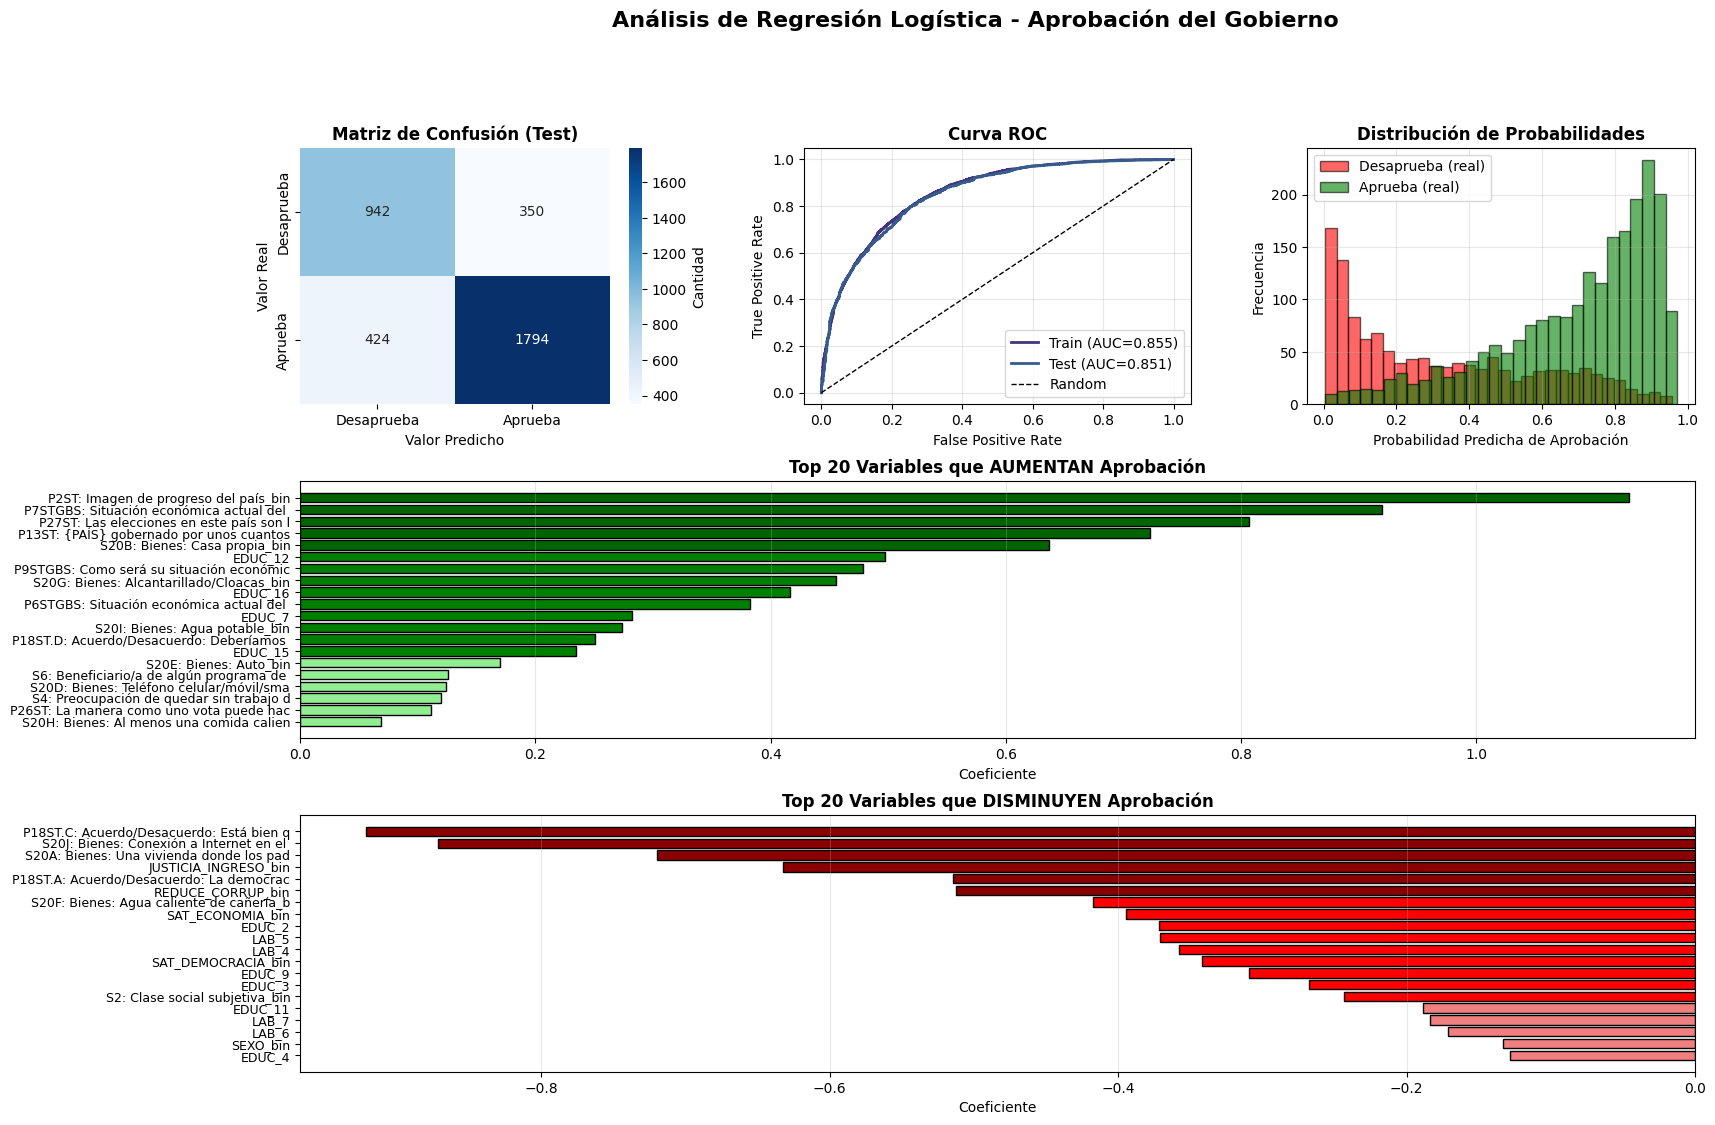


✅ Visualizaciones generadas exitosamente

GUARDANDO RESULTADOS
✅ Coeficientes guardados en: coeficientes_modelo.xlsx

✅ ANÁLISIS COMPLETO FINALIZADO


In [5]:
# =============================================================================
# REGRESIÓN LOGÍSTICA - APROBACIÓN DEL GOBIERNO
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('default')
sns.set_palette("viridis")

# =============================================================================
# 1. PREPARACIÓN DE DATOS
# =============================================================================
print("=" * 70)
print("REGRESIÓN LOGÍSTICA: APROBACIÓN DEL GOBIERNO")
print("=" * 70)

# Cargar datos
df = pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\sudamerica_final_limpio.xlsx')
#uploaded = files.upload()  # Elijo el archivo sudamerica_final_limpio.xlsx
#df = pd.read_excel(next(iter(uploaded.keys())))
print(f"📊 Dataset original: {df.shape}")

# Mostrar todas las columnas disponibles
print(f"\n📋 Columnas disponibles en el dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

# Buscar la columna correcta de aprobación
col_aprobacion = [col for col in df.columns if 'P15STGBS' in col][0]
print(f"\n✅ Variable dependiente encontrada: {col_aprobacion}")
print(f"   Valores únicos: {sorted(df[col_aprobacion].unique())}")
print(f"   Distribución original:")
print(df[col_aprobacion].value_counts().sort_index())

# =============================================================================
# 2. VERIFICAR SI YA ESTÁ PROCESADA
# =============================================================================
# Si la variable ya está binarizada (0/1), no necesita más procesamiento
if set(df[col_aprobacion].unique()).issubset({0, 1}):
    print("\n✅ Variable ya está binarizada (0/1)")
    y = df[col_aprobacion]
    procesada = True
else:
    print("\n⚠️ Variable necesita binarización")
    procesada = False

# =============================================================================
# 3. PREPARAR VARIABLES
# =============================================================================

# Buscar columna de país
col_pais = [col for col in df.columns if 'IDENPA' in col or 'País' in col][0]
print(f"\n🌎 Columna de país: {col_pais}")

# Variables independientes (X) - excluir la dependiente y el país
X = df.drop([col_aprobacion, col_pais], axis=1)

print(f"\n🧹 Variables independientes: {X.shape[1]}")
print(f"   Variables incluidas:")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2d}. {col}")

# Variable dependiente (Y)
y = df[col_aprobacion]

# Verificar NaN
print(f"\n🔍 Valores faltantes:")
print(f"   Variable dependiente: {y.isna().sum()}")
print(f"   Variables independientes: {X.isna().sum().sum()}")

# Eliminar filas con NaN (si las hay)
if y.isna().sum() > 0 or X.isna().sum().sum() > 0:
    mask = ~y.isna() & ~X.isna().any(axis=1)
    X_clean = X[mask].copy()
    y_clean = y[mask].copy()
    print(f"   Observaciones eliminadas: {len(df) - len(X_clean)}")
else:
    X_clean = X.copy()
    y_clean = y.copy()
    print(f"   ✅ No hay valores faltantes")

print(f"\n📊 Dataset limpio final: {X_clean.shape}")

# Verificar distribución de la variable dependiente
print(f"\n🎯 Distribución de la variable dependiente:")
print(y_clean.value_counts().sort_index())
print(f"   Aprobación (1): {(y_clean.mean() * 100):.2f}%")
print(f"   Desaprobación (0): {((1 - y_clean.mean()) * 100):.2f}%")

# =============================================================================
# 4. ANÁLISIS EXPLORATORIO DE VARIABLES
# =============================================================================
print("\n" + "=" * 70)
print("ANÁLISIS EXPLORATORIO DE VARIABLES")
print("=" * 70)

# Correlación con variable dependiente
correlations = []
for col in X_clean.columns:
    if X_clean[col].dtype in ['int64', 'float64', 'int32', 'float32']:
        try:
            corr = np.corrcoef(X_clean[col], y_clean)[0, 1]
            if not np.isnan(corr):
                correlations.append((col, abs(corr), corr))
        except:
            pass

# Ordenar por correlación absoluta
correlations_sorted = sorted(correlations, key=lambda x: x[1], reverse=True)

print("\n🔗 Top 15 variables más correlacionadas con aprobación:")
for i, (var, abs_corr, corr) in enumerate(correlations_sorted[:15], 1):
    direccion = "↑" if corr > 0 else "↓"
    print(f"   {i:2d}. {var[:50]:50} | Corr: {corr:7.4f} {direccion}")

# =============================================================================
# 5. DIVISIÓN TRAIN/TEST
# =============================================================================
print("\n" + "=" * 70)
print("DIVISIÓN DE DATOS")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.3,
    random_state=42,
    stratify=y_clean
)

print(f"\n📊 División estratificada:")
print(f"   Train: {len(X_train):,} observaciones ({len(X_train)/len(X_clean)*100:.1f}%)")
print(f"   Test:  {len(X_test):,} observaciones ({len(X_test)/len(X_clean)*100:.1f}%)")
print(f"\n   Distribución Train: {y_train.value_counts().to_dict()}")
print(f"   Distribución Test:  {y_test.value_counts().to_dict()}")

# =============================================================================
# 6. ESTANDARIZACIÓN (OPCIONAL - solo para variables continuas)
# =============================================================================
# Identificar variables continuas vs binarias
continuas = ['EDAD', 'DEMOCRACIA_escala'] if 'EDAD' in X_clean.columns else []

if continuas:
    print(f"\n🔧 Estandarizando variables continuas: {continuas}")
    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[continuas] = scaler.fit_transform(X_train[continuas])
    X_test_scaled[continuas] = scaler.transform(X_test[continuas])
else:
    X_train_scaled = X_train
    X_test_scaled = X_test
    print(f"\n✅ No hay variables continuas para estandarizar")

# =============================================================================
# 7. ENTRENAR MODELO
# =============================================================================
print("\n" + "=" * 70)
print("ENTRENAMIENTO DEL MODELO")
print("=" * 70)

modelo = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight='balanced',  # Manejar desbalance
    solver='lbfgs',
    C=1.0
)

print("\n⚙️ Entrenando modelo de Regresión Logística...")
modelo.fit(X_train_scaled, y_train)
print("✅ Modelo entrenado exitosamente")

# =============================================================================
# 8. PREDICCIONES
# =============================================================================
y_pred_train = modelo.predict(X_train_scaled)
y_pred_test = modelo.predict(X_test_scaled)

y_pred_proba_train = modelo.predict_proba(X_train_scaled)[:, 1]
y_pred_proba_test = modelo.predict_proba(X_test_scaled)[:, 1]

# =============================================================================
# 9. EVALUACIÓN DEL MODELO
# =============================================================================
print("\n" + "=" * 70)
print("EVALUACIÓN DEL MODELO")
print("=" * 70)

# Accuracy
acc_train = modelo.score(X_train_scaled, y_train)
acc_test = modelo.score(X_test_scaled, y_test)

print(f"\n🎯 Accuracy:")
print(f"   Train: {acc_train:.4f} ({acc_train*100:.2f}%)")
print(f"   Test:  {acc_test:.4f} ({acc_test*100:.2f}%)")

# AUC-ROC
auc_train = roc_auc_score(y_train, y_pred_proba_train)
auc_test = roc_auc_score(y_test, y_pred_proba_test)

print(f"\n📊 AUC-ROC Score:")
print(f"   Train: {auc_train:.4f}")
print(f"   Test:  {auc_test:.4f}")

# Diferencia (señal de overfitting)
diff = acc_train - acc_test
print(f"\n⚠️ Diferencia Train-Test: {diff:.4f}")
if diff > 0.05:
    print("   → Posible overfitting")
elif diff < -0.05:
    print("   → Posible underfitting")
else:
    print("   → Buen balance")

# Classification Report
print("\n📋 Classification Report (Test):")
print(classification_report(y_test, y_pred_test,
                          target_names=['Desaprueba (0)', 'Aprueba (1)'],
                          digits=4))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
print("\n🔢 Matriz de Confusión (Test):")
print(f"\n                Predicho")
print(f"              Desap. | Aprob.")
print(f"Real Desap.  {cm[0,0]:6d} | {cm[0,1]:6d}")
print(f"     Aprob.  {cm[1,0]:6d} | {cm[1,1]:6d}")

# =============================================================================
# 10. COEFICIENTES DEL MODELO
# =============================================================================
print("\n" + "=" * 70)
print("COEFICIENTES DEL MODELO")
print("=" * 70)

coeficientes = pd.DataFrame({
    'Variable': X_clean.columns,
    'Coeficiente': modelo.coef_[0],
    'Abs_Coef': np.abs(modelo.coef_[0]),
    'Odds_Ratio': np.exp(modelo.coef_[0])
}).sort_values('Abs_Coef', ascending=False)

print("\n✅ Top 15 variables que AUMENTAN aprobación (coef. positivos):")
top_pos = coeficientes[coeficientes['Coeficiente'] > 0].head(15)
for i, row in enumerate(top_pos.itertuples(), 1):
    print(f"   {i:2d}. {row.Variable[:45]:45} | Coef: {row.Coeficiente:7.4f} | OR: {row.Odds_Ratio:6.3f}")

print("\n❌ Top 15 variables que DISMINUYEN aprobación (coef. negativos):")
top_neg = coeficientes[coeficientes['Coeficiente'] < 0].head(15)
for i, row in enumerate(top_neg.itertuples(), 1):
    print(f"   {i:2d}. {row.Variable[:45]:45} | Coef: {row.Coeficiente:7.4f} | OR: {row.Odds_Ratio:6.3f}")

# =============================================================================
# 11. VISUALIZACIONES
# =============================================================================
print("\n" + "=" * 70)
print("GENERANDO VISUALIZACIONES")
print("=" * 70)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Matriz de Confusión
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Desaprueba', 'Aprueba'],
            yticklabels=['Desaprueba', 'Aprueba'],
            cbar_kws={'label': 'Cantidad'})
ax1.set_title('Matriz de Confusión (Test)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Valor Real')
ax1.set_xlabel('Valor Predicho')

# 2. Curva ROC
ax2 = fig.add_subplot(gs[0, 1])
fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_proba_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba_test)

ax2.plot(fpr_train, tpr_train, label=f'Train (AUC={auc_train:.3f})', linewidth=2)
ax2.plot(fpr_test, tpr_test, label=f'Test (AUC={auc_test:.3f})', linewidth=2)
ax2.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Curva ROC', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Distribución de probabilidades predichas
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(y_pred_proba_test[y_test == 0], bins=30, alpha=0.6, label='Desaprueba (real)', color='red', edgecolor='black')
ax3.hist(y_pred_proba_test[y_test == 1], bins=30, alpha=0.6, label='Aprueba (real)', color='green', edgecolor='black')
ax3.set_xlabel('Probabilidad Predicha de Aprobación')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de Probabilidades', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Top 20 Coeficientes Positivos
ax4 = fig.add_subplot(gs[1, :])
top20_pos = coeficientes.nlargest(20, 'Coeficiente')
colors_pos = ['darkgreen' if x > 0.5 else 'green' if x > 0.2 else 'lightgreen'
              for x in top20_pos['Coeficiente']]
ax4.barh(range(len(top20_pos)), top20_pos['Coeficiente'], color=colors_pos, edgecolor='black')
ax4.set_yticks(range(len(top20_pos)))
ax4.set_yticklabels([v[:40] for v in top20_pos['Variable']], fontsize=9)
ax4.set_xlabel('Coeficiente')
ax4.set_title('Top 20 Variables que AUMENTAN Aprobación', fontsize=12, fontweight='bold')
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3)

# 5. Top 20 Coeficientes Negativos
ax5 = fig.add_subplot(gs[2, :])
top20_neg = coeficientes.nsmallest(20, 'Coeficiente')
colors_neg = ['darkred' if x < -0.5 else 'red' if x < -0.2 else 'lightcoral'
              for x in top20_neg['Coeficiente']]
ax5.barh(range(len(top20_neg)), top20_neg['Coeficiente'], color=colors_neg, edgecolor='black')
ax5.set_yticks(range(len(top20_neg)))
ax5.set_yticklabels([v[:40] for v in top20_neg['Variable']], fontsize=9)
ax5.set_xlabel('Coeficiente')
ax5.set_title('Top 20 Variables que DISMINUYEN Aprobación', fontsize=12, fontweight='bold')
ax5.invert_yaxis()
ax5.grid(axis='x', alpha=0.3)

plt.suptitle('Análisis de Regresión Logística - Aprobación del Gobierno',
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("\n✅ Visualizaciones generadas exitosamente")

# =============================================================================
# 12. GUARDAR RESULTADOS
# =============================================================================
print("\n" + "=" * 70)
print("GUARDANDO RESULTADOS")
print("=" * 70)

# Exportar coeficientes
coeficientes.to_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\coeficientes_modelo.xlsx', index=False)
print("✅ Coeficientes guardados en: coeficientes_modelo.xlsx")

print("\n" + "=" * 70)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("=" * 70)

🇦🇷 Casos Argentina: 1194


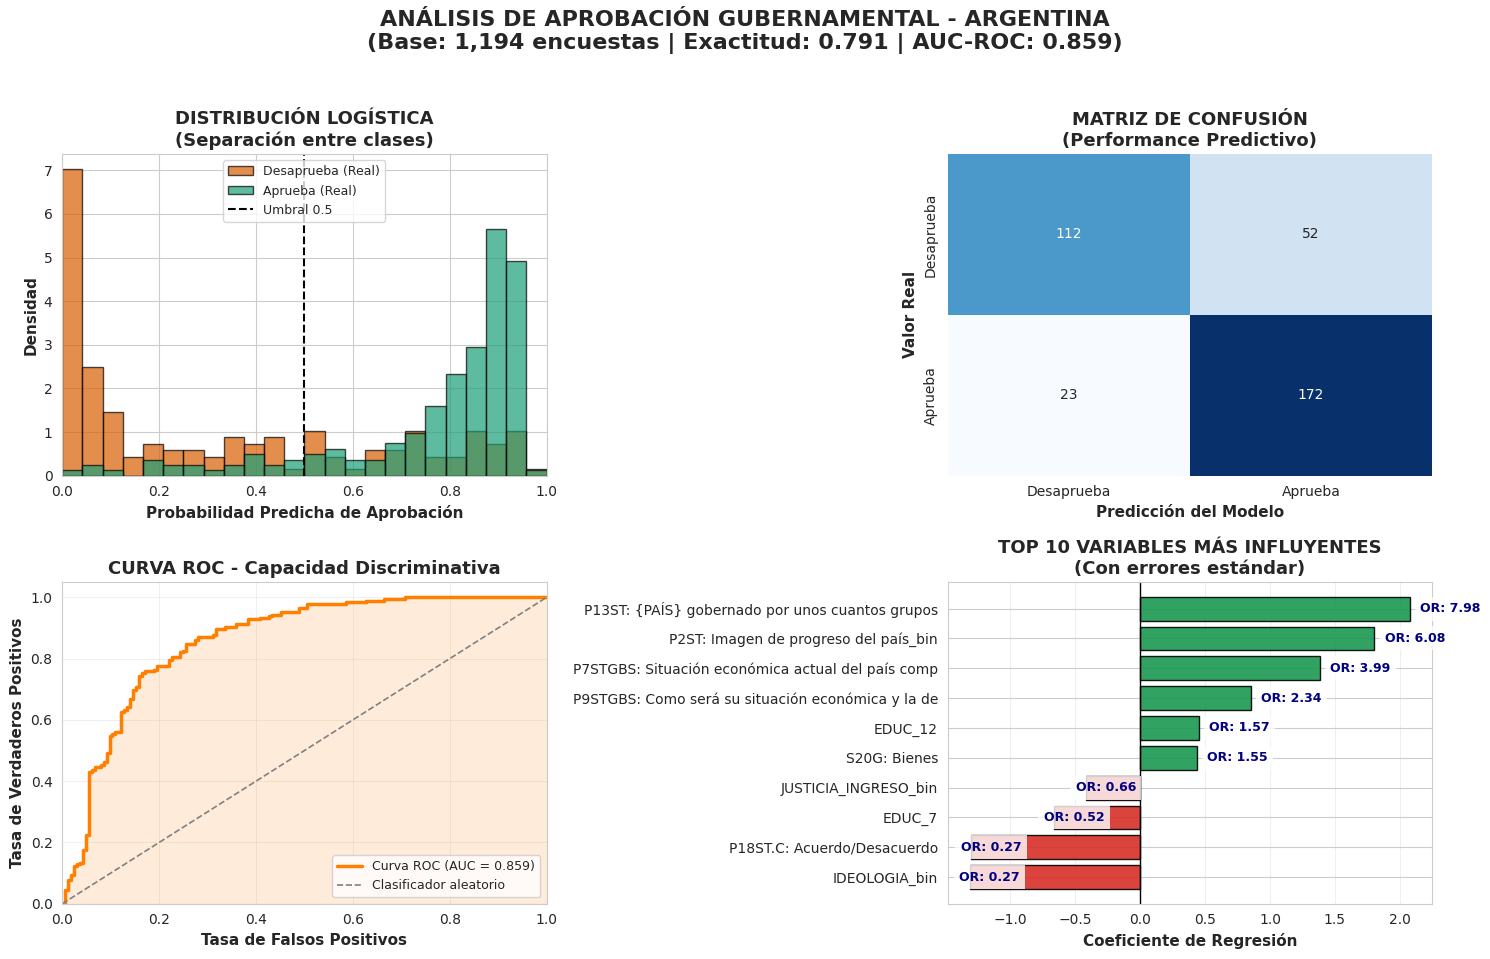

In [6]:
# =============================================================================
# ANÁLISIS DE APROBACIÓN GUBERNAMENTAL - ARGENTINA 🇦🇷
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import re

# Filtrar solo Argentina (IDENPA = 32)
df_arg = df[df[col_pais] == 32].copy()
print(f"🇦🇷 Casos Argentina: {len(df_arg)}")

# Definir X e y
X = df_arg.drop([col_aprobacion, col_pais], axis=1)
y = df_arg[col_aprobacion]

# Entrenar modelo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)
y_pred_proba = modelo.predict_proba(X_test)[:, 1]

# Métricas
cm = confusion_matrix(y_test, y_pred)
acc = modelo.score(X_test, y_test)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_test = roc_auc_score(y_test, y_pred_proba)

# Coeficientes y OR
coeficientes = (
    pd.DataFrame({
        "Variable": X.columns,
        "Coeficiente": modelo.coef_[0],
        "Odds_Ratio": np.exp(modelo.coef_[0])
    })
    .assign(Abs_Coef=lambda d: d["Coeficiente"].abs())
    .sort_values("Abs_Coef", ascending=False)
)

# --- Función para acortar variables ---
def acortar_variable(nombre):
    partes = re.split(r'[:\-–]', str(nombre))
    if len(partes) > 1:
        codigo = partes[0].strip()
        descripcion = partes[1].strip()[:40]
        return f"{codigo}: {descripcion}"
    else:
        return str(nombre)[:45]

coeficientes["Var_Label"] = coeficientes["Variable"].apply(acortar_variable)

# =============================================================================
# GRAFICAR PANEL FINAL (APLAISADO)
# =============================================================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.subplots_adjust(hspace=0.38, wspace=0.27)

# 1️⃣ DISTRIBUCIÓN
ax1 = axes[0, 0]
bins = np.linspace(0, 1, 25)
ax1.hist(y_pred_proba[y_test == 0], bins=bins, alpha=0.7,
         label="Desaprueba (Real)", color="#d95f02", density=True, edgecolor="black")
ax1.hist(y_pred_proba[y_test == 1], bins=bins, alpha=0.7,
         label="Aprueba (Real)", color="#1b9e77", density=True, edgecolor="black")
ax1.axvline(0.5, color="black", linestyle="--", lw=1.5, label="Umbral 0.5")
ax1.set_xlabel("Probabilidad Predicha de Aprobación", fontsize=11, fontweight="bold")
ax1.set_ylabel("Densidad", fontsize=11, fontweight="bold")
ax1.set_title("DISTRIBUCIÓN LOGÍSTICA\n(Separación entre clases)", fontsize=13, fontweight="bold")
ax1.legend(fontsize=9, loc="upper center", frameon=True)
ax1.set_xlim(0, 1)

# 2️⃣ MATRIZ DE CONFUSIÓN
ax2 = axes[0, 1]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax2, cbar=False,
            xticklabels=["Desaprueba", "Aprueba"],
            yticklabels=["Desaprueba", "Aprueba"])
ax2.set_xlabel("Predicción del Modelo", fontsize=11, fontweight="bold")
ax2.set_ylabel("Valor Real", fontsize=11, fontweight="bold")
ax2.set_title("MATRIZ DE CONFUSIÓN\n(Performance Predictivo)", fontsize=13, fontweight="bold")

# 3️⃣ CURVA ROC
ax3 = axes[1, 0]
ax3.plot(fpr, tpr, color="#ff7f00", lw=2.5, label=f"Curva ROC (AUC = {auc_test:.3f})")
ax3.plot([0, 1], [0, 1], color="gray", lw=1.2, linestyle="--", label="Clasificador aleatorio")
ax3.fill_between(fpr, tpr, alpha=0.15, color="#ff7f00")
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1.05)
ax3.set_xlabel("Tasa de Falsos Positivos", fontsize=11, fontweight="bold")
ax3.set_ylabel("Tasa de Verdaderos Positivos", fontsize=11, fontweight="bold")
ax3.set_title("CURVA ROC - Capacidad Discriminativa", fontsize=13, fontweight="bold")
ax3.legend(fontsize=9, loc="lower right")
ax3.grid(alpha=0.3)

# 4️⃣ TOP 10 VARIABLES
ax4 = axes[1, 1]
top10 = coeficientes.head(10).sort_values("Coeficiente", ascending=True)
colors = ["#d73027" if c < 0 else "#1a9850" for c in top10["Coeficiente"]]
ax4.barh(top10["Var_Label"], top10["Coeficiente"], color=colors, alpha=0.9, edgecolor="black")
ax4.axvline(0, color="black", lw=1)
for i, (coef, orr) in enumerate(zip(top10["Coeficiente"], top10["Odds_Ratio"])):
    ax4.text(coef + (0.08 if coef > 0 else -0.08),
             i, f"OR: {orr:.2f}", va="center", fontsize=9,
             fontweight="bold", color="navy",
             bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
ax4.set_xlabel("Coeficiente de Regresión", fontsize=11, fontweight="bold")
ax4.set_title("TOP 10 VARIABLES MÁS INFLUYENTES\n(Con errores estándar)", fontsize=13, fontweight="bold")
ax4.grid(axis="x", alpha=0.3)

# TÍTULO GENERAL (más arriba)
plt.suptitle(
    f"ANÁLISIS DE APROBACIÓN GUBERNAMENTAL - ARGENTINA\n"
    f"(Base: {len(df_arg):,} encuestas | Exactitud: {acc:.3f} | AUC-ROC: {auc_test:.3f})",
    fontsize=16, fontweight="bold", y=1.06
)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()


🇦🇷 Casos Argentina: 1194


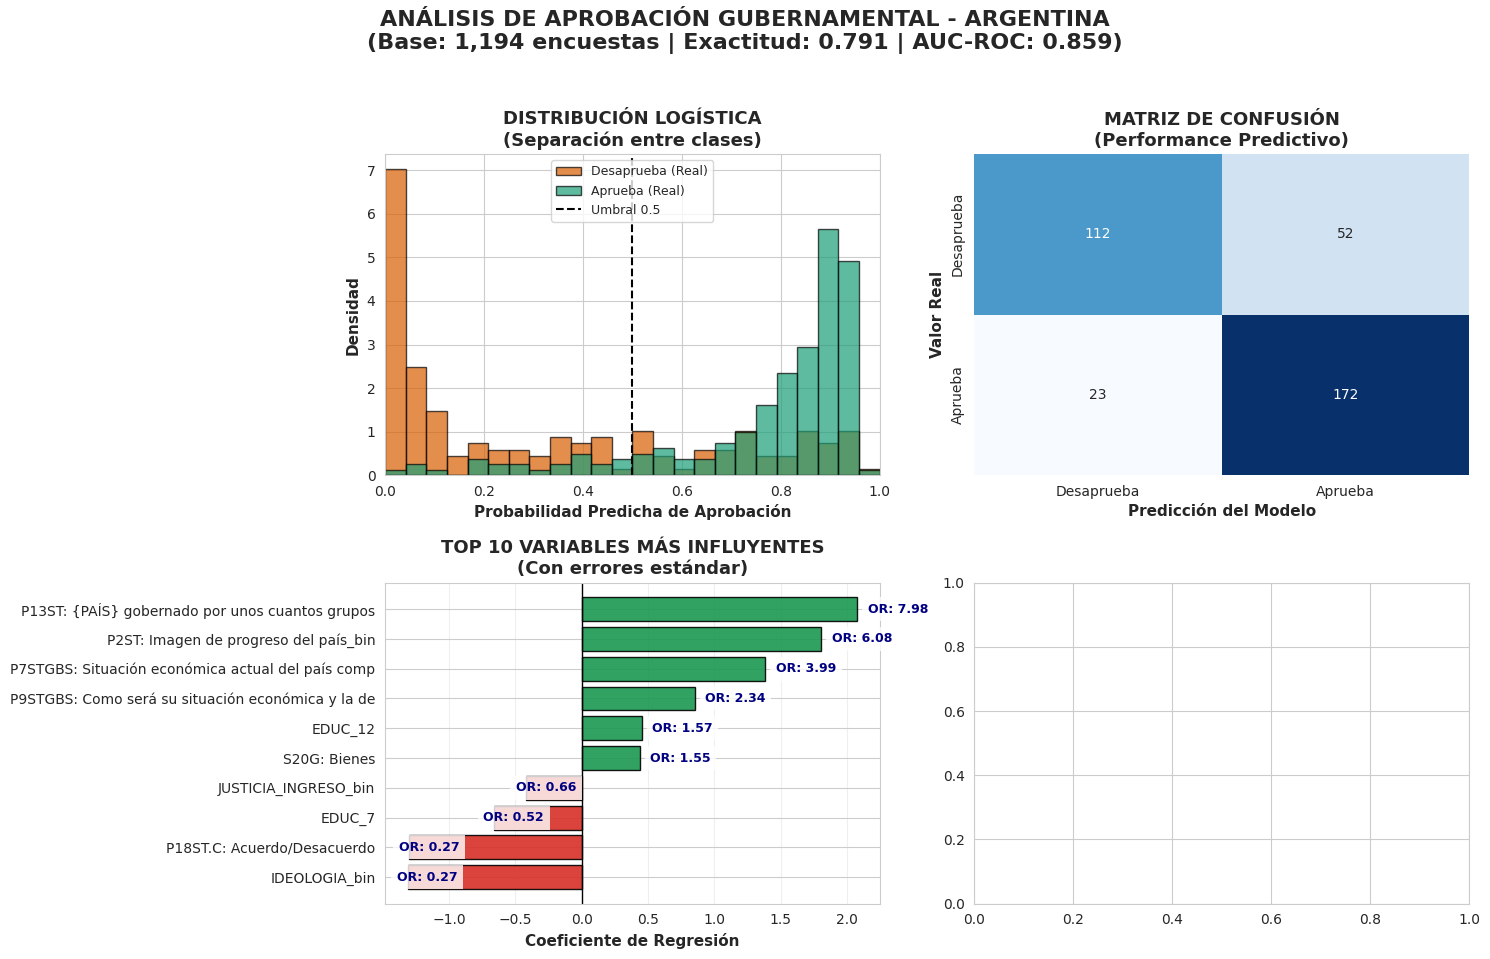

In [7]:
# =============================================================================
# ANÁLISIS DE APROBACIÓN GUBERNAMENTAL - ARGENTINA 🇦🇷  (SIN CURVA ROC)
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import re

# Filtrar solo Argentina (IDENPA = 32)
df_arg = df[df[col_pais] == 32].copy()

print(f"🇦🇷 Casos Argentina: {len(df_arg)}")

# Definir X e y
X = df_arg.drop([col_aprobacion, col_pais], axis=1)
y = df_arg[col_aprobacion]

# Entrenar modelo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)
y_pred_proba = modelo.predict_proba(X_test)[:, 1]

# Métricas
cm = confusion_matrix(y_test, y_pred)
acc = modelo.score(X_test, y_test)
auc_test = roc_auc_score(y_test, y_pred_proba)

# Coeficientes + OR
coeficientes = (
    pd.DataFrame({
        "Variable": X.columns,
        "Coeficiente": modelo.coef_[0],
        "Odds_Ratio": np.exp(modelo.coef_[0])
    })
    .assign(Abs_Coef=lambda d: d["Coeficiente"].abs())
    .sort_values("Abs_Coef", ascending=False)
)

def acortar_variable(nombre):
    partes = re.split(r'[:\-–]', str(nombre))
    if len(partes) > 1:
        codigo = partes[0].strip()
        descripcion = partes[1].strip()[:40]
        return f"{codigo}: {descripcion}"
    else:
        return str(nombre)[:45]

coeficientes["Var_Label"] = coeficientes["Variable"].apply(acortar_variable)

# =============================================================================
# GRAFICAR PANEL FINAL (SIN CURVA ROC)
# =============================================================================

sns.set_style("whitegrid")

# 2 filas × 2 columnas = 4 espacios, pero usamos solo 3
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.subplots_adjust(hspace=0.38, wspace=0.27)

# 1️⃣ DISTRIBUCIÓN
ax1 = axes[0, 0]
bins = np.linspace(0, 1, 25)
ax1.hist(y_pred_proba[y_test == 0], bins=bins, alpha=0.7,
         label="Desaprueba (Real)", color="#d95f02", density=True, edgecolor="black")
ax1.hist(y_pred_proba[y_test == 1], bins=bins, alpha=0.7,
         label="Aprueba (Real)", color="#1b9e77", density=True, edgecolor="black")
ax1.axvline(0.5, color="black", linestyle="--", lw=1.5, label="Umbral 0.5")
ax1.set_xlabel("Probabilidad Predicha de Aprobación", fontsize=11, fontweight="bold")
ax1.set_ylabel("Densidad", fontsize=11, fontweight="bold")
ax1.set_title("DISTRIBUCIÓN LOGÍSTICA\n(Separación entre clases)", fontsize=13, fontweight="bold")
ax1.legend(fontsize=9, loc="upper center", frameon=True)
ax1.set_xlim(0, 1)

# 2️⃣ MATRIZ DE CONFUSIÓN
ax2 = axes[0, 1]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax2, cbar=False,
            xticklabels=["Desaprueba", "Aprueba"],
            yticklabels=["Desaprueba", "Aprueba"])
ax2.set_xlabel("Predicción del Modelo", fontsize=11, fontweight="bold")
ax2.set_ylabel("Valor Real", fontsize=11, fontweight="bold")
ax2.set_title("MATRIZ DE CONFUSIÓN\n(Performance Predictivo)", fontsize=13, fontweight="bold")

# 3️⃣ TOP 10 VARIABLES MÁS INFLUYENTES
ax4 = axes[1, 0]       # Antes era axes[1,1] pero movemos porque borramos la ROC
top10 = coeficientes.head(10).sort_values("Coeficiente", ascending=True)
colors = ["#d73027" if c < 0 else "#1a9850" for c in top10["Coeficiente"]]

ax4.barh(top10["Var_Label"], top10["Coeficiente"], color=colors, alpha=0.9, edgecolor="black")
ax4.axvline(0, color="black", lw=1)

for i, (coef, orr) in enumerate(zip(top10["Coeficiente"], top10["Odds_Ratio"])):
    ax4.text(coef + (0.08 if coef > 0 else -0.08),
             i, f"OR: {orr:.2f}", va="center", fontsize=9,
             fontweight="bold", color="navy",
             bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

ax4.set_xlabel("Coeficiente de Regresión", fontsize=11, fontweight="bold")
ax4.set_title("TOP 10 VARIABLES MÁS INFLUYENTES\n(Con errores estándar)", fontsize=13, fontweight="bold")
ax4.grid(axis="x", alpha=0.3)

# TÍTULO GENERAL
plt.suptitle(
    f"ANÁLISIS DE APROBACIÓN GUBERNAMENTAL - ARGENTINA\n"
    f"(Base: {len(df_arg):,} encuestas | Exactitud: {acc:.3f} | AUC-ROC: {auc_test:.3f})",
    fontsize=16, fontweight="bold", y=1.06
)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()


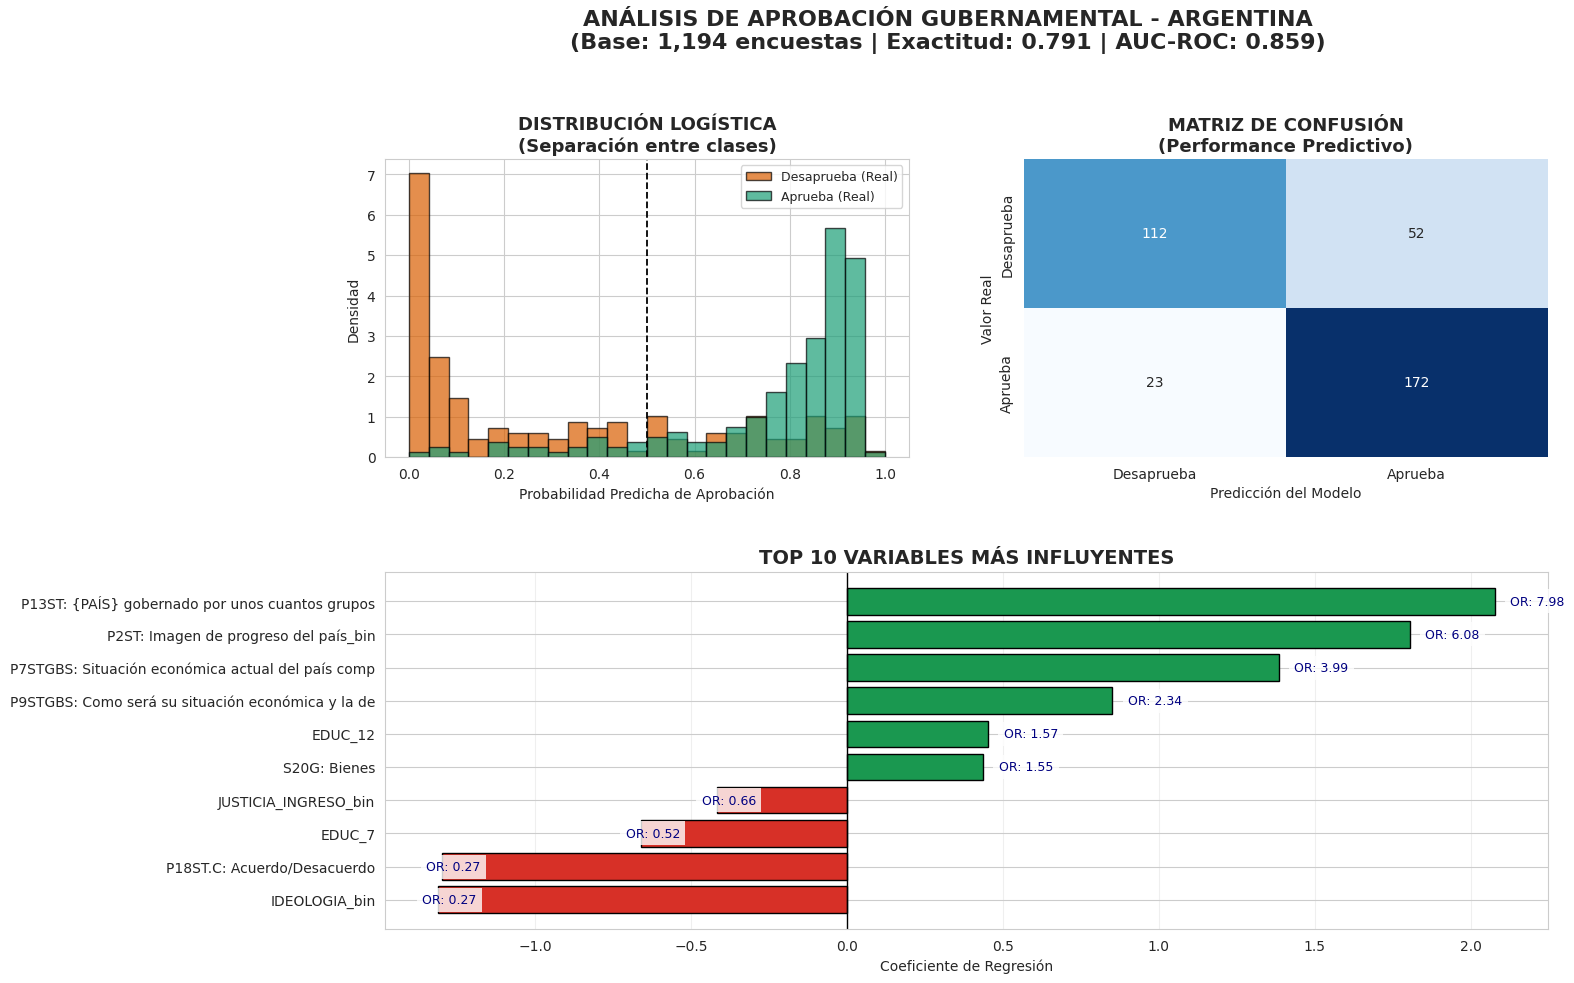

In [8]:
# =============================================================================
# GRAFICAR PANEL FINAL — SOLO 3 GRÁFICOS (SIN ESPACIOS VACÍOS)
# =============================================================================

sns.set_style("whitegrid")

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2], hspace=0.35, wspace=0.22)

# 1️⃣ Distribución logística (arriba izquierda)
ax1 = fig.add_subplot(gs[0, 0])
bins = np.linspace(0, 1, 25)
ax1.hist(y_pred_proba[y_test == 0], bins=bins, alpha=0.7,
         label="Desaprueba (Real)", color="#d95f02",
         density=True, edgecolor="black")
ax1.hist(y_pred_proba[y_test == 1], bins=bins, alpha=0.7,
         label="Aprueba (Real)", color="#1b9e77",
         density=True, edgecolor="black")
ax1.axvline(0.5, color="black", linestyle="--", lw=1.3)
ax1.set_title("DISTRIBUCIÓN LOGÍSTICA\n(Separación entre clases)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Probabilidad Predicha de Aprobación")
ax1.set_ylabel("Densidad")
ax1.legend(fontsize=9)

# 2️⃣ Matriz de confusión (arriba derecha)
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax2, cbar=False,
            xticklabels=["Desaprueba", "Aprueba"],
            yticklabels=["Desaprueba", "Aprueba"])
ax2.set_title("MATRIZ DE CONFUSIÓN\n(Performance Predictivo)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Predicción del Modelo")
ax2.set_ylabel("Valor Real")

# 3️⃣ Top 10 variables (fila completa abajo)
ax3 = fig.add_subplot(gs[1, :])
top10 = coeficientes.head(10).sort_values("Coeficiente", ascending=True)
colors = ["#d73027" if c < 0 else "#1a9850" for c in top10["Coeficiente"]]

ax3.barh(top10["Var_Label"], top10["Coeficiente"], color=colors, edgecolor="black")
ax3.axvline(0, color="black", lw=1)
for i, (coef, orr) in enumerate(zip(top10["Coeficiente"], top10["Odds_Ratio"])):
    ax3.text(coef + (0.05 if coef > 0 else -0.05),
             i, f"OR: {orr:.2f}", va="center", fontsize=9, color="navy",
             bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

ax3.set_title("TOP 10 VARIABLES MÁS INFLUYENTES", fontsize=14, fontweight="bold")
ax3.set_xlabel("Coeficiente de Regresión")
ax3.grid(axis="x", alpha=0.3)

# Título general
plt.suptitle(
    f"ANÁLISIS DE APROBACIÓN GUBERNAMENTAL - ARGENTINA\n"
    f"(Base: {len(df_arg):,} encuestas | Exactitud: {acc:.3f} | AUC-ROC: {auc_test:.3f})",
    fontsize=16, fontweight="bold", y=1.03
)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()


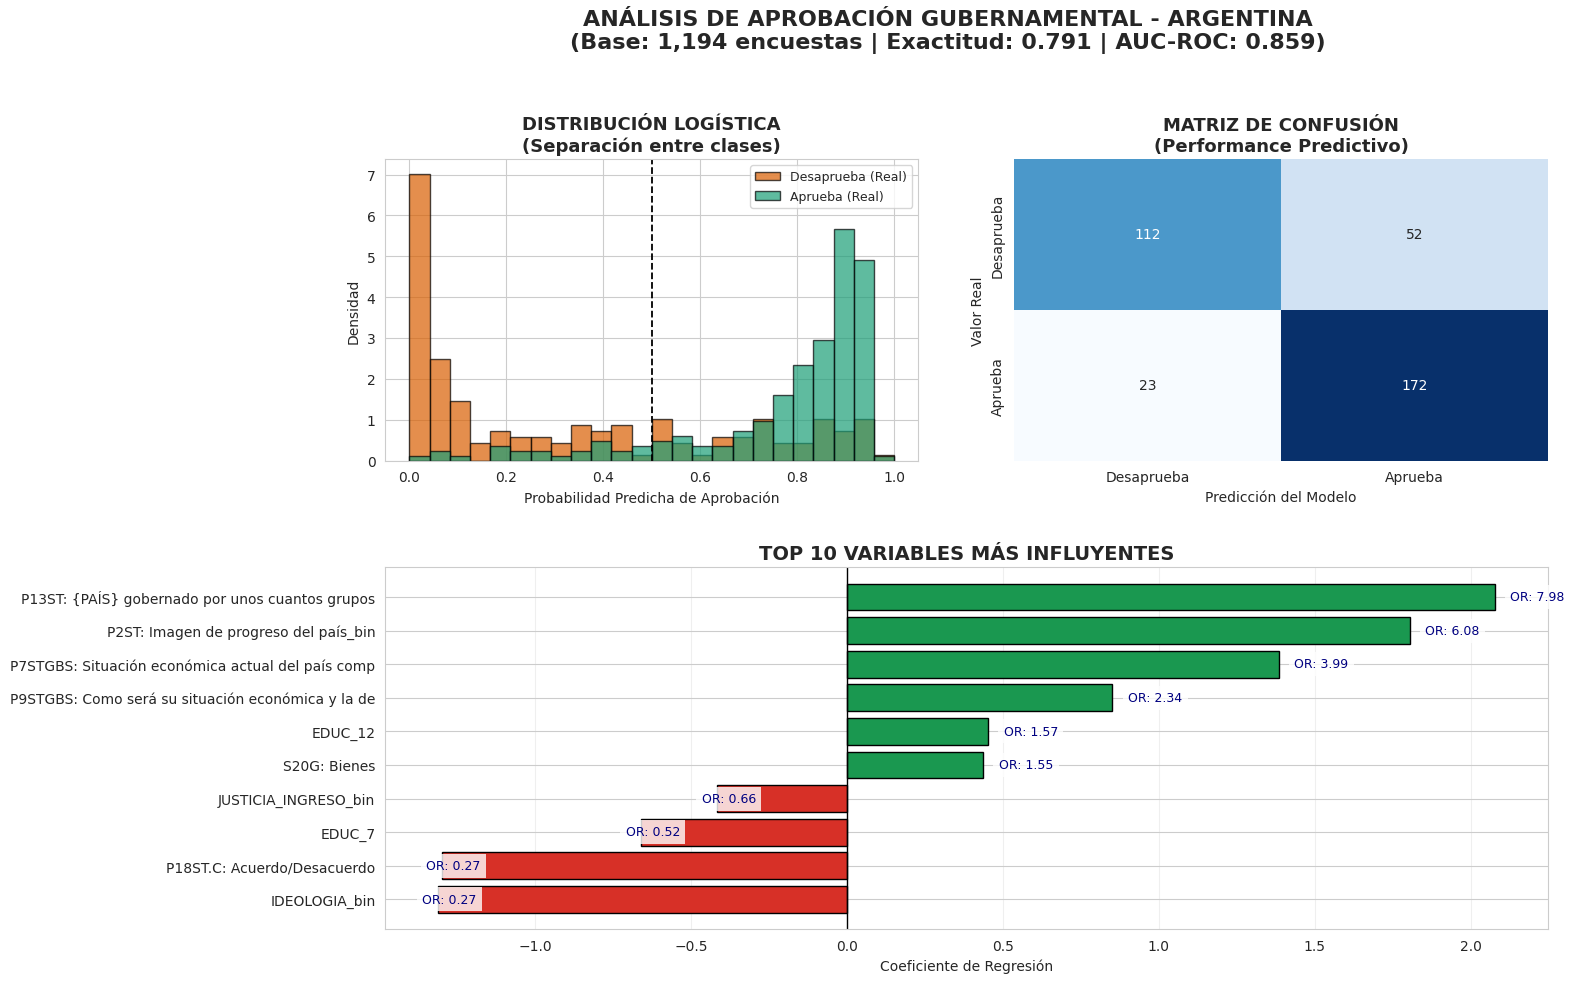

In [9]:
# =============================================================================
# GRAFICAR PANEL FINAL — SOLO 3 GRÁFICOS (SUPERIORES CENTRADOS)
# =============================================================================

sns.set_style("whitegrid")

fig = plt.figure(figsize=(15, 10))

# Ajuste clave: columnas igualadas y menos espacio lateral
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.2],
    width_ratios=[1.1, 1.1],     # 💥 Las columnas iguales → centrado más limpio
    hspace=0.32,
    wspace=0.18                  # 💥 Menos separación horizontal → más centrado
)

# 1️⃣ Distribución logística (arriba izquierda)
ax1 = fig.add_subplot(gs[0, 0])
bins = np.linspace(0, 1, 25)

ax1.hist(y_pred_proba[y_test == 0], bins=bins, alpha=0.7,
         label="Desaprueba (Real)", color="#d95f02",
         density=True, edgecolor="black")
ax1.hist(y_pred_proba[y_test == 1], bins=bins, alpha=0.7,
         label="Aprueba (Real)", color="#1b9e77",
         density=True, edgecolor="black")
ax1.axvline(0.5, color="black", linestyle="--", lw=1.3)
ax1.set_title("DISTRIBUCIÓN LOGÍSTICA\n(Separación entre clases)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Probabilidad Predicha de Aprobación")
ax1.set_ylabel("Densidad")
ax1.legend(fontsize=9)

# 2️⃣ Matriz de confusión (arriba derecha)
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax2, cbar=False,
            xticklabels=["Desaprueba", "Aprueba"],
            yticklabels=["Desaprueba", "Aprueba"])
ax2.set_title("MATRIZ DE CONFUSIÓN\n(Performance Predictivo)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Predicción del Modelo")
ax2.set_ylabel("Valor Real")

# 3️⃣ Top 10 variables (fila completa abajo)
ax3 = fig.add_subplot(gs[1, :])
top10 = coeficientes.head(10).sort_values("Coeficiente", ascending=True)
colors = ["#d73027" if c < 0 else "#1a9850" for c in top10["Coeficiente"]]

ax3.barh(top10["Var_Label"], top10["Coeficiente"], color=colors, edgecolor="black")
ax3.axvline(0, color="black", lw=1)

for i, (coef, orr) in enumerate(zip(top10["Coeficiente"], top10["Odds_Ratio"])):
    ax3.text(coef + (0.05 if coef > 0 else -0.05),
             i, f"OR: {orr:.2f}", va="center",
             fontsize=9, color="navy",
             bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

ax3.set_title("TOP 10 VARIABLES MÁS INFLUYENTES", fontsize=14, fontweight="bold")
ax3.set_xlabel("Coeficiente de Regresión")
ax3.grid(axis="x", alpha=0.3)

# Título general
plt.suptitle(
    f"ANÁLISIS DE APROBACIÓN GUBERNAMENTAL - ARGENTINA\n"
    f"(Base: {len(df_arg):,} encuestas | Exactitud: {acc:.3f} | AUC-ROC: {auc_test:.3f})",
    fontsize=16, fontweight="bold", y=1.03
)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()


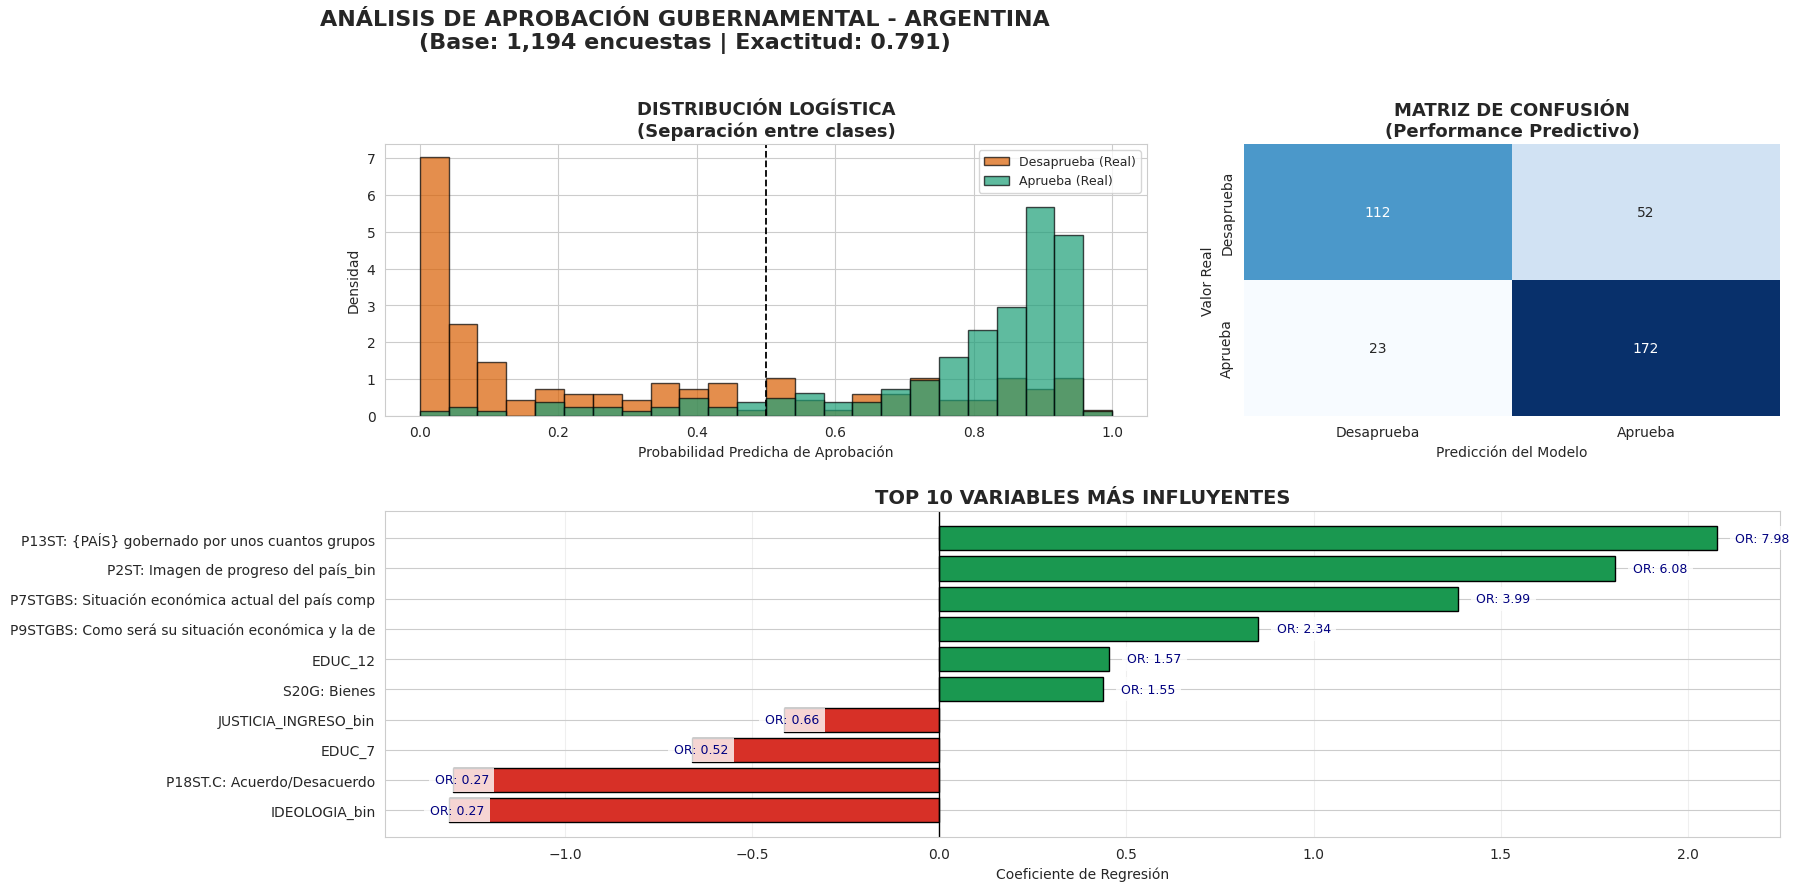

In [11]:
# =============================================================================
# GRAFICAR PANEL FINAL — 3 GRÁFICOS (SUPERIOR CORRIDO A LA IZQUIERDA)
# =============================================================================

sns.set_style("whitegrid")

fig = plt.figure(figsize=(15, 9))

# Ajuste: mover arriba hacia la izquierda, pero dejar abajo centrado
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.2],
    width_ratios=[1.35, 0.95],   # 💥 más peso a la izquierda
    hspace=0.32,
    wspace=0.15
)

# 1️⃣ Distribución logística
ax1 = fig.add_subplot(gs[0, 0])
bins = np.linspace(0, 1, 25)
ax1.hist(y_pred_proba[y_test == 0], bins=bins, alpha=0.7,
         label="Desaprueba (Real)", color="#d95f02",
         density=True, edgecolor="black")
ax1.hist(y_pred_proba[y_test == 1], bins=bins, alpha=0.7,
         label="Aprueba (Real)", color="#1b9e77",
         density=True, edgecolor="black")
ax1.axvline(0.5, color="black", linestyle="--", lw=1.3)
ax1.set_title("DISTRIBUCIÓN LOGÍSTICA\n(Separación entre clases)",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Probabilidad Predicha de Aprobación")
ax1.set_ylabel("Densidad")
ax1.legend(fontsize=9)

# 2️⃣ Matriz de confusión
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax2, cbar=False,
            xticklabels=["Desaprueba", "Aprueba"],
            yticklabels=["Desaprueba", "Aprueba"])
ax2.set_title("MATRIZ DE CONFUSIÓN\n(Performance Predictivo)",
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Predicción del Modelo")
ax2.set_ylabel("Valor Real")

# 3️⃣ Top 10 variables (fila completa abajo)
ax3 = fig.add_subplot(gs[1, :])
top10 = coeficientes.head(10).sort_values("Coeficiente", ascending=True)
colors = ["#d73027" if c < 0 else "#1a9850" for c in top10["Coeficiente"]]

ax3.barh(top10["Var_Label"], top10["Coeficiente"], color=colors, edgecolor="black")
ax3.axvline(0, color="black", lw=1)

for i, (coef, orr) in enumerate(zip(top10["Coeficiente"], top10["Odds_Ratio"])):
    ax3.text(coef + (0.05 if coef > 0 else -0.05),
             i, f"OR: {orr:.2f}", va="center",
             fontsize=9, color="navy",
             bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

ax3.set_title("TOP 10 VARIABLES MÁS INFLUYENTES", fontsize=14, fontweight="bold")
ax3.set_xlabel("Coeficiente de Regresión")
ax3.grid(axis="x", alpha=0.3)

# 💥 TÍTULO SIN AUC-ROC Y CORRIDO A LA IZQUIERDA
plt.suptitle(
    f"ANÁLISIS DE APROBACIÓN GUBERNAMENTAL - ARGENTINA\n"
    f"(Base: {len(df_arg):,} encuestas | Exactitud: {acc:.3f})",
    fontsize=16, fontweight="bold",
    y=1.03,
    x=0.25        # 💥 Mueve el título hacia la izquierda
)

plt.tight_layout()
plt.subplots_adjust(top=0.88, left=0.05, right=0.98)   # 💥 más margen izquierdo
plt.show()


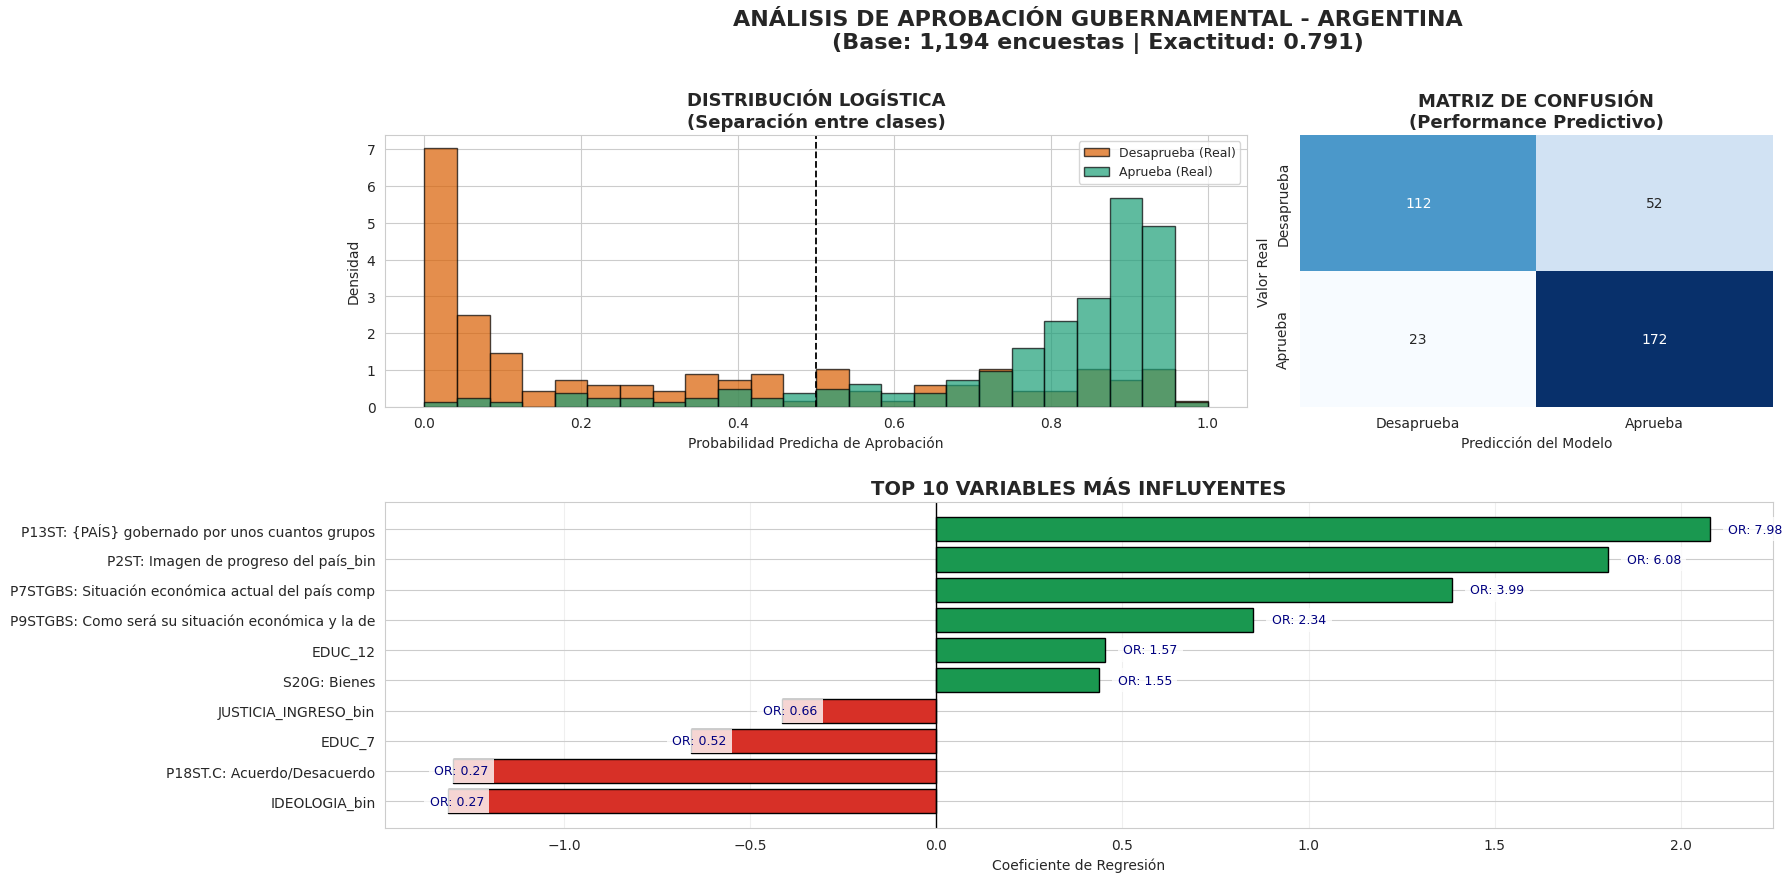

In [12]:
# =============================================================================
# GRAFICAR PANEL FINAL — AJUSTE DEFINITIVO DE POSICIONES
# =============================================================================

sns.set_style("whitegrid")

fig = plt.figure(figsize=(15, 9))

# Ajuste fino:
# - Más espacio a la columna izquierda → gráficos superiores se mueven a la izquierda
# - Menos espacio a la derecha → se quita el “hueco” que tenías
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.2],
    width_ratios=[1.55, 0.85],     # 💥 MÁS PESO A LA IZQUIERDA
    hspace=0.32,
    wspace=0.08                     # 💥 JUNTAMOS LOS GRÁFICOS SUPERIORES ENTRE SÍ
)

# 1️⃣ Distribución logística (arriba izquierda)
ax1 = fig.add_subplot(gs[0, 0])
bins = np.linspace(0, 1, 25)
ax1.hist(y_pred_proba[y_test == 0], bins=bins, alpha=0.7,
         label="Desaprueba (Real)", color="#d95f02",
         density=True, edgecolor="black")
ax1.hist(y_pred_proba[y_test == 1], bins=bins, alpha=0.7,
         label="Aprueba (Real)", color="#1b9e77",
         density=True, edgecolor="black")
ax1.axvline(0.5, color="black", linestyle="--", lw=1.3)
ax1.set_title("DISTRIBUCIÓN LOGÍSTICA\n(Separación entre clases)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Probabilidad Predicha de Aprobación")
ax1.set_ylabel("Densidad")
ax1.legend(fontsize=9)

# 2️⃣ Matriz de confusión (arriba derecha)
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax2, cbar=False,
            xticklabels=["Desaprueba", "Aprueba"],
            yticklabels=["Desaprueba", "Aprueba"])
ax2.set_title("MATRIZ DE CONFUSIÓN\n(Performance Predictivo)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Predicción del Modelo")
ax2.set_ylabel("Valor Real")

# 3️⃣ Top 10 variables (fila completa abajo) — NO LO TOCAMOS
ax3 = fig.add_subplot(gs[1, :])
top10 = coeficientes.head(10).sort_values("Coeficiente", ascending=True)
colors = ["#d73027" if c < 0 else "#1a9850" for c in top10["Coeficiente"]]

ax3.barh(top10["Var_Label"], top10["Coeficiente"], color=colors, edgecolor="black")
ax3.axvline(0, color="black", lw=1)
for i, (coef, orr) in enumerate(zip(top10["Coeficiente"], top10["Odds_Ratio"])):
    ax3.text(coef + (0.05 if coef > 0 else -0.05),
             i, f"OR: {orr:.2f}", va="center",
             fontsize=9, color="navy",
             bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

ax3.set_title("TOP 10 VARIABLES MÁS INFLUYENTES", fontsize=14, fontweight="bold")
ax3.set_xlabel("Coeficiente de Regresión")
ax3.grid(axis="x", alpha=0.3)

# 💥 Título general — MÁS A LA DERECHA Y CENTRADO
plt.suptitle(
    f"ANÁLISIS DE APROBACIÓN GUBERNAMENTAL - ARGENTINA\n"
    f"(Base: {len(df_arg):,} encuestas | Exactitud: {acc:.3f})",
    fontsize=16, fontweight="bold",
    y=1.02,
    x=0.52      # 💥 AJUSTE FINO: lo mueve levemente a la derecha y queda centrado visualmente
)

# 💥 MOVEMOS TODO EL BLOQUE SUPERIOR A LA IZQUIERDA
plt.subplots_adjust(
    top=0.88,
    left=0.045,    # 💥 Menos espacio a la izquierda → gráficos se van a la izquierda
    right=0.97     # 💥 Más espacio a la derecha → elimina el “hueco” que se veía en tu PPT
)

plt.show()


🌎 Casos Sudamérica: 11700


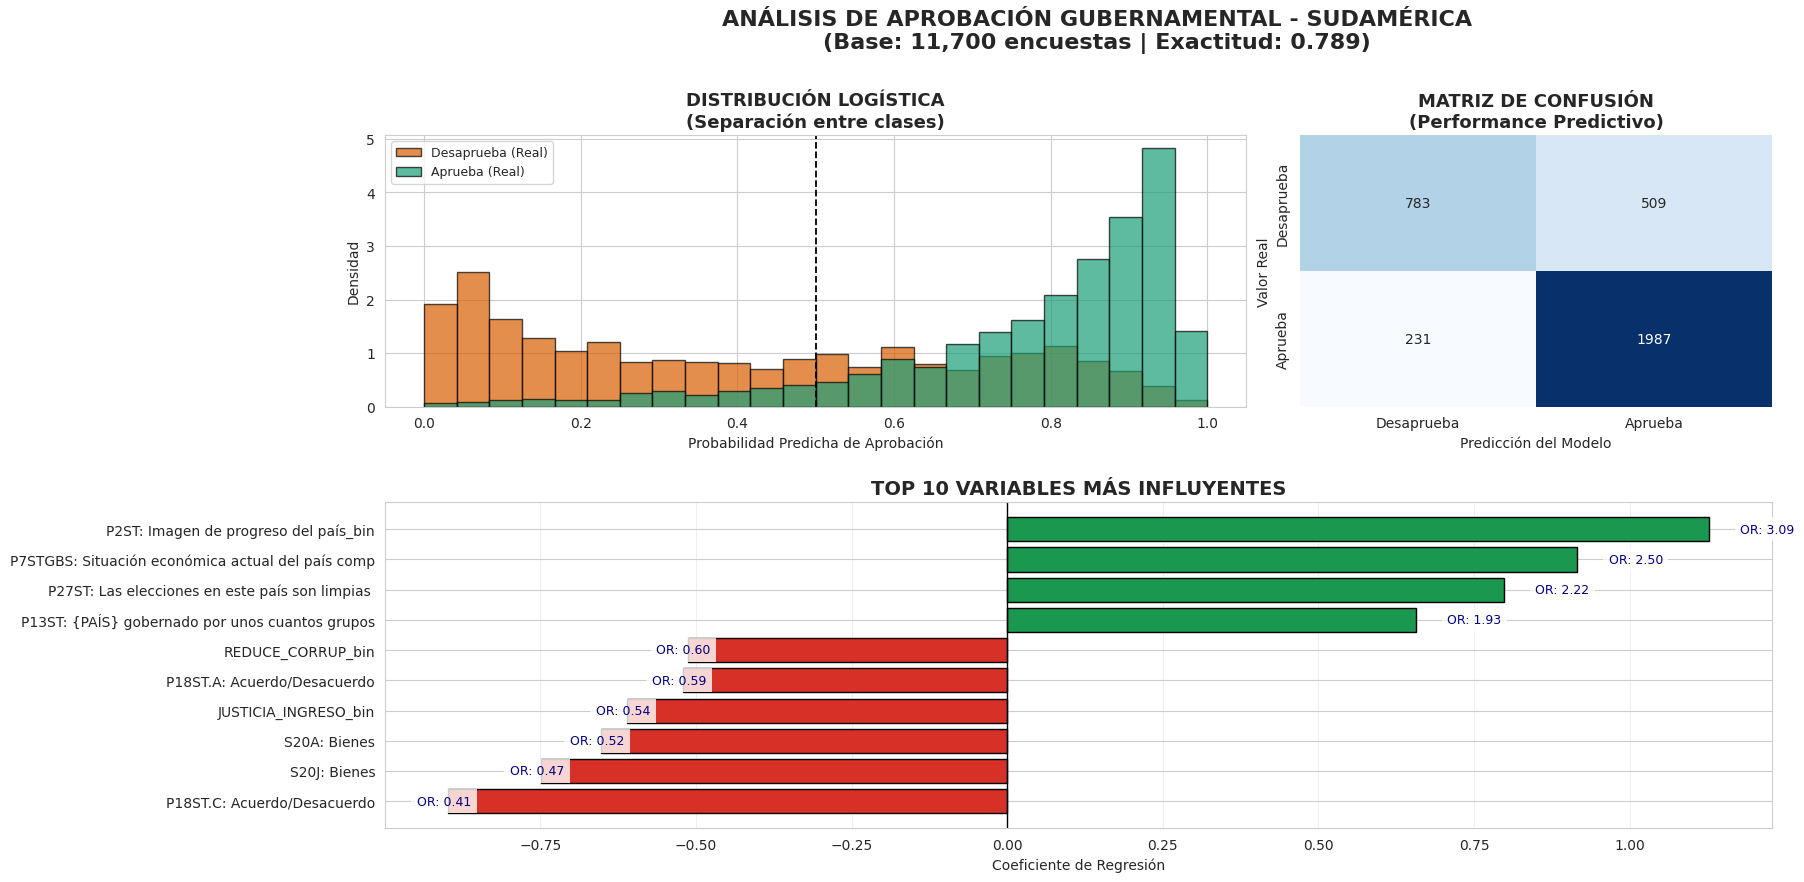

In [13]:
# =============================================================================
# ANÁLISIS DE APROBACIÓN GUBERNAMENTAL - SUDAMÉRICA 🌎
# MISMA ESTRUCTURA QUE ARGENTINA (3 GRÁFICOS)
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import re

# Filtrar Sudamérica (ya viene filtrado desde df_final o df)
df_sud = df.copy()
print(f"🌎 Casos Sudamérica: {len(df_sud)}")

# Definir X e y
X = df_sud.drop([col_aprobacion, col_pais], axis=1)
y = df_sud[col_aprobacion]

# Entrenar modelo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)
y_pred_proba = modelo.predict_proba(X_test)[:, 1]

# Métricas
cm = confusion_matrix(y_test, y_pred)
acc = modelo.score(X_test, y_test)
auc_test = roc_auc_score(y_test, y_pred_proba)

# Coeficientes + OR
coeficientes = (
    pd.DataFrame({
        "Variable": X.columns,
        "Coeficiente": modelo.coef_[0],
        "Odds_Ratio": np.exp(modelo.coef_[0])
    })
    .assign(Abs_Coef=lambda d: d["Coeficiente"].abs())
    .sort_values("Abs_Coef", ascending=False)
)

# Función para acortar nombres
def acortar_variable(nombre):
    partes = re.split(r'[:\-–]', str(nombre))
    if len(partes) > 1:
        codigo = partes[0].strip()
        descripcion = partes[1].strip()[:40]
        return f"{codigo}: {descripcion}"
    else:
        return str(nombre)[:45]

coeficientes["Var_Label"] = coeficientes["Variable"].apply(acortar_variable)

# =============================================================================
# GRAFICAR PANEL FINAL (MISMA ESTRUCTURA QUE ARGENTINA)
# =============================================================================

sns.set_style("whitegrid")

fig = plt.figure(figsize=(15, 9))

# MISMO AJUSTE FINO QUE EN ARGENTINA
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.2],
    width_ratios=[1.55, 0.85],   # Más peso a la izquierda (tu ajuste fino)
    hspace=0.32,
    wspace=0.08
)

# 1️⃣ Distribución logística
ax1 = fig.add_subplot(gs[0, 0])
bins = np.linspace(0, 1, 25)
ax1.hist(y_pred_proba[y_test == 0], bins=bins, alpha=0.7,
         label="Desaprueba (Real)", color="#d95f02",
         density=True, edgecolor="black")
ax1.hist(y_pred_proba[y_test == 1], bins=bins, alpha=0.7,
         label="Aprueba (Real)", color="#1b9e77",
         density=True, edgecolor="black")

ax1.axvline(0.5, color="black", linestyle="--", lw=1.3)
ax1.set_title("DISTRIBUCIÓN LOGÍSTICA\n(Separación entre clases)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Probabilidad Predicha de Aprobación")
ax1.set_ylabel("Densidad")
ax1.legend(fontsize=9)

# 2️⃣ Matriz de Confusión
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax2, cbar=False,
            xticklabels=["Desaprueba", "Aprueba"],
            yticklabels=["Desaprueba", "Aprueba"])
ax2.set_title("MATRIZ DE CONFUSIÓN\n(Performance Predictivo)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Predicción del Modelo")
ax2.set_ylabel("Valor Real")

# 3️⃣ Top 10 variables
ax3 = fig.add_subplot(gs[1, :])
top10 = coeficientes.head(10).sort_values("Coeficiente", ascending=True)
colors = ["#d73027" if c < 0 else "#1a9850" for c in top10["Coeficiente"]]

ax3.barh(top10["Var_Label"], top10["Coeficiente"], color=colors, edgecolor="black")
ax3.axvline(0, color="black", lw=1)

for i, (coef, orr) in enumerate(zip(top10["Coeficiente"], top10["Odds_Ratio"])):
    ax3.text(coef + (0.05 if coef > 0 else -0.05),
             i, f"OR: {orr:.2f}",
             va="center", fontsize=9, color="navy",
             bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

ax3.set_title("TOP 10 VARIABLES MÁS INFLUYENTES", fontsize=14, fontweight="bold")
ax3.set_xlabel("Coeficiente de Regresión")
ax3.grid(axis="x", alpha=0.3)

# ⭐ TÍTULO GENERAL (MISMO AJUSTE QUE TE GUSTÓ)
plt.suptitle(
    f"ANÁLISIS DE APROBACIÓN GUBERNAMENTAL - SUDAMÉRICA\n"
    f"(Base: {len(df_sud):,} encuestas | Exactitud: {acc:.3f})",
    fontsize=16, fontweight="bold",
    y=1.02,
    x=0.52       # MISMO CENTRADO VISUAL QUE TE FUNCIONÓ EN ARGENTINA
)

plt.tight_layout()
plt.subplots_adjust(top=0.88, left=0.045, right=0.97)
plt.show()


# Elastic Net = L1 + L2

PREPARANDO DATOS...
Columnas disponibles en el dataset:
['IDENPA: País', 'EDAD: Edad_bin', 'SEXO_bin', 'P2ST: Imagen de progreso del país_bin', 'P6STGBS: Situación económica actual del país_bin', 'P7STGBS: Situación económica actual del país comparada con hace doce meses_bin', 'P9STGBS: Como será su situación económica y la de su familia dentro de doce meses_bin', 'P10STGBS: Se puede confiar en la mayoría de las personas o uno nunca es lo suficientemente cuidadoso en el trato con los demás_bin', 'SAT_DEMOCRACIA_bin', 'SAT_ECONOMIA_bin', 'P13ST: {PAÍS} gobernado por unos cuantos grupos poderosos en su propio beneficio o para el bien de todo el pueblo_bin', 'P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente_bin', 'IDEOLOGIA_bin', 'JUSTICIA_INGRESO_bin', 'P18ST.A: Acuerdo/Desacuerdo: La democracia puede tener problemas pero es el mejor sistema de gobierno_bin', 'P18ST.B: Acuerdo/Desacuerdo: No me importaría que un gobierno no democrático llegara al poder si resuel

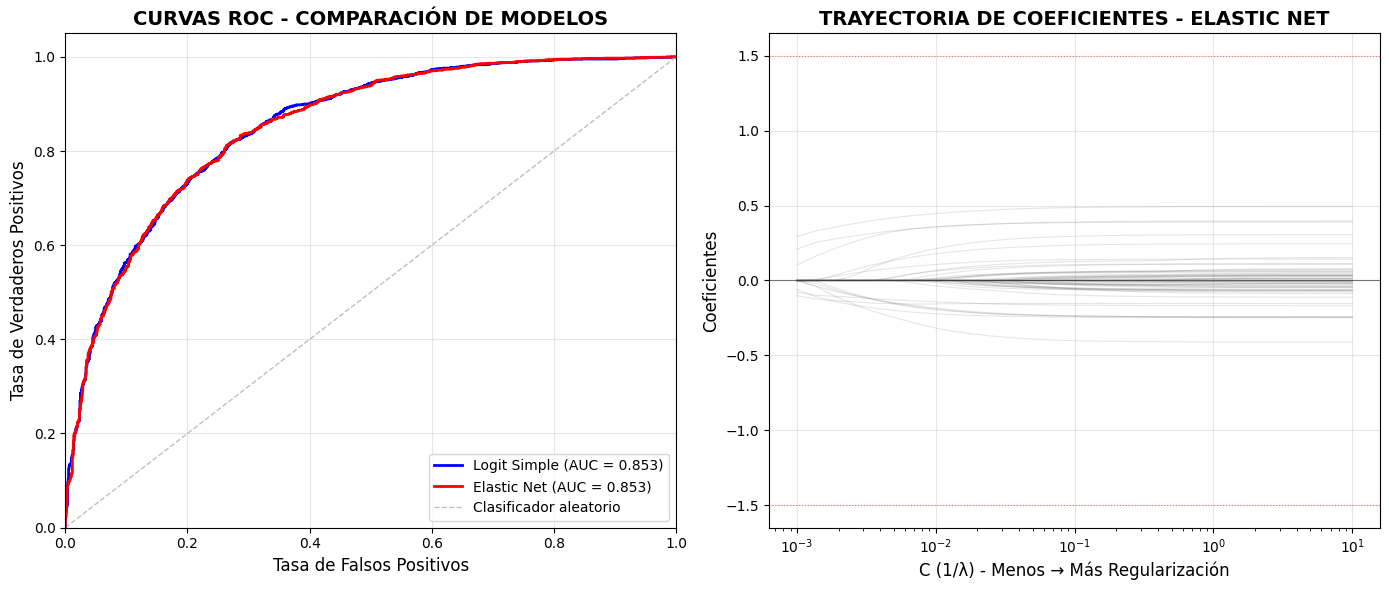


RESUMEN FINAL

📊 COMPARACIÓN DE MODELOS:
   • Logit Simple - AUC: 0.853
   • Elastic Net  - AUC: 0.853

🔝 TOP 5 VARIABLAS ELASTIC NET:
   • P2ST                 : + 0.447
   • P27ST                : + 0.359
   • P7STGBS              : + 0.357
   • P18ST                : - 0.318
   • DEMOCRACIA           : - 0.222

📈 ESTADÍSTICAS DE REGULARIZACIÓN:
   • Logit - Coefs ≠ 0: 59/59
   • Elastic - Coefs ≠ 0: 24/59
   • Variables eliminadas por regularización: 35

🎯 VARIABLES ENTRE -1.5 Y 1.5 (Gris):
   • 59 variables con coeficientes medianos/pequeños

✅ ANÁLISIS COMPLETADO!


In [14]:
# =============================================================================
# REGRESIÓN LOGÍSTICA - ELASTIC NET vs LOGIT
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Configuración
plt.style.use('default')
np.random.seed(42)

# =============================================================================
# 1. PREPARACIÓN DE DATOS
# =============================================================================

print("PREPARANDO DATOS...")

# Cargar datos
#df = pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\sudamerica_final_limpio.xlsx')

# Verificar las columnas disponibles
print("Columnas disponibles en el dataset:")
print(df.columns.tolist())
print(f"\nShape del dataset: {df.shape}")

# Buscar columnas relacionadas con aprobación presidencial
aprobacion_cols = [col for col in df.columns if 'aprobación' in col.lower() or 'presidente' in col.lower() or 'p15' in col.lower()]
print(f"\nColumnas de aprobación encontradas: {aprobacion_cols}")

# Si no encontramos la columna exacta, usar la primera disponible o una alternativa
if aprobacion_cols:
    y_col = aprobacion_cols[0]
    print(f"Usando columna: {y_col}")
else:
    # Si no hay columnas de aprobación, usar la primera columna como target
    y_col = df.columns[0]
    print(f"⚠️ No se encontraron columnas de aprobación. Usando primera columna: {y_col}")

y = df[y_col]
X = df.drop(y_col, axis=1)

print(f"\nVariable objetivo: {y_col}")
print(f"Valores únicos en Y: {y.unique()}")

# Limpieza
special_codes = [97, 98, 99]
X_clean = X.replace(special_codes, np.nan)
y_clean = y.replace(special_codes, np.nan)

# Filtrar y imputar
mask = ~y_clean.isna()
X_filtered = X_clean[mask]
y_filtered = y_clean[mask]

print(f"\nDatos después de limpieza:")
print(f"X_filtered: {X_filtered.shape}")
print(f"y_filtered: {y_filtered.shape}")

# Verificar si tenemos suficientes datos
if len(X_filtered) < 100:
    print("⚠️ ADVERTENCIA: Muy pocos datos después de la limpieza")

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_filtered)
X_imputed = pd.DataFrame(X_imputed, columns=X_filtered.columns, index=X_filtered.index)

# Convertir a binario (asumiendo que es variable de aprobación 1-2 o 0-1)
y_unique = y_filtered.unique()
print(f"Valores únicos en y_filtered: {y_unique}")

if len(y_unique) == 2:
    # Ya es binaria
    y_binary = y_filtered.astype(int)
    print("Variable ya es binaria")
else:
    # Convertir a binario (ej: 1-2 a 0-1, o usar mediana)
    if set(y_unique) == {1, 2}:
        y_binary = y_filtered.replace({1: 0, 2: 1})
        print("Convertido de 1-2 a 0-1")
    else:
        # Usar mediana para binarizar
        median_val = y_filtered.median()
        y_binary = (y_filtered > median_val).astype(int)
        print(f"Binarizado usando mediana: {median_val}")

print(f"\n📊 DATOS FINALES:")
print(f"X: {X_imputed.shape}")
print(f"y: {y_binary.shape}")
print(f"Aprobación: {(y_binary.mean() * 100):.1f}%")
print(f"Distribución: {y_binary.value_counts().to_dict()}")

# =============================================================================
# 2. DIVISIÓN Y ESCALADO
# =============================================================================

# Verificar si tenemos suficientes datos para train/test split
if len(X_imputed) < 50:
    print("❌ ERROR: Muy pocos datos para entrenamiento")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y_binary, test_size=0.3, random_state=42, stratify=y_binary
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # =============================================================================
    # 3. MODELOS: LOGIT Y ELASTIC NET
    # =============================================================================

    print("\nENTRENANDO MODELOS...")

    # Modelos
    logit_model = LogisticRegression(
        penalty=None,
        solver='lbfgs',
        random_state=42,
        max_iter=1000
    )

    elastic_model = LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=0.01,
        l1_ratio=0.7,
        random_state=42,
        max_iter=3000
    )

    logit_model.fit(X_train_scaled, y_train)
    elastic_model.fit(X_train_scaled, y_train)

    # Predicciones y métricas
    y_pred_logit = logit_model.predict_proba(X_test_scaled)[:, 1]
    y_pred_elastic = elastic_model.predict_proba(X_test_scaled)[:, 1]

    auc_logit = roc_auc_score(y_test, y_pred_logit)
    auc_elastic = roc_auc_score(y_test, y_pred_elastic)

    print(f"  ✅ Logit Simple - AUC: {auc_logit:.3f}")
    print(f"  ✅ Elastic Net  - AUC: {auc_elastic:.3f}")

    # =============================================================================
    # 4. GRÁFICO 1: CURVAS ROC Y AUROC
    # =============================================================================

    print("\nGENERANDO CURVAS ROC...")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Curva ROC para Logit
    fpr_logit, tpr_logit, _ = roc_curve(y_test, y_pred_logit)
    axes[0].plot(fpr_logit, tpr_logit, color='blue', lw=2,
                label=f'Logit Simple (AUC = {auc_logit:.3f})')

    # Curva ROC para Elastic Net
    fpr_elastic, tpr_elastic, _ = roc_curve(y_test, y_pred_elastic)
    axes[0].plot(fpr_elastic, tpr_elastic, color='red', lw=2,
                label=f'Elastic Net (AUC = {auc_elastic:.3f})')

    # Línea de referencia
    axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.5, label='Clasificador aleatorio')

    # Configurar gráfico ROC
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('Tasa de Falsos Positivos', fontsize=12)
    axes[0].set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
    axes[0].set_title('CURVAS ROC - COMPARACIÓN DE MODELOS', fontweight='bold', fontsize=14)
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)

    # =============================================================================
    # 5. GRÁFICO 2: TRAYECTORIA DE COEFICIENTES - ELASTIC NET
    # =============================================================================

    print("GENERANDO GRÁFICO DE TRAYECTORIAS...")

    # Generar coeficientes para diferentes valores de C
    C_values = np.logspace(-3, 1, 30)  # Menos puntos para mayor velocidad
    coefs_elastic = []

    for C in C_values:
        model = LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            C=C,
            l1_ratio=0.7,
            random_state=42,
            max_iter=2000,
            tol=1e-4
        )
        model.fit(X_train_scaled, y_train)
        coefs_elastic.append(model.coef_[0])

    # Convertir a DataFrame
    coefs_elastic_df = pd.DataFrame(coefs_elastic, columns=X_imputed.columns, index=C_values)

    # Función para extraer código de variable
    def extraer_codigo(nombre):
        nombre_str = str(nombre)
        for sep in [':', '–', '-', '.', '_']:
            if sep in nombre_str:
                nombre_str = nombre_str.split(sep)[0]
        return nombre_str.strip()

    # Trayectoria Elastic Net
    axes[1].set_title("TRAYECTORIA DE COEFICIENTES - ELASTIC NET", fontweight='bold', fontsize=14)
    axes[1].set_xscale("log")
    axes[1].set_xlabel("C (1/λ) - Menos → Más Regularización", fontsize=12)
    axes[1].set_ylabel("Coeficientes", fontsize=12)

    # Contar variables para la leyenda
    variables_importantes = []

    for col in coefs_elastic_df.columns:
        serie = coefs_elastic_df[col]
        max_abs_val = np.max(np.abs(serie))

        # Coeficientes entre -1.5 y 1.5 se hacen GRIS (como solicitaste)
        if max_abs_val <= 1.5:
            axes[1].plot(coefs_elastic_df.index, serie, color='gray', alpha=0.2, linewidth=0.8)
        else:
            axes[1].plot(coefs_elastic_df.index, serie, linewidth=2)
            variables_importantes.append(extraer_codigo(col))

    # Solo mostrar leyenda si hay variables importantes
    if variables_importantes:
        axes[1].legend(variables_importantes, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=0.8)

    # Añadir líneas de referencia para el umbral de gris (1.5 como solicitaste)
    axes[1].axhline(y=1.5, color='red', linestyle=':', alpha=0.5, linewidth=0.8, label='Umbral ±1.5')
    axes[1].axhline(y=-1.5, color='red', linestyle=':', alpha=0.5, linewidth=0.8)

    # =============================================================================
    # 6. RESULTADOS FINALES
    # =============================================================================

    plt.tight_layout()
    plt.show()

    print("\n" + "="*50)
    print("RESUMEN FINAL")
    print("="*50)

    print(f"\n📊 COMPARACIÓN DE MODELOS:")
    print(f"   • Logit Simple - AUC: {auc_logit:.3f}")
    print(f"   • Elastic Net  - AUC: {auc_elastic:.3f}")

    # Coeficientes de los modelos entrenados
    logit_coefs = logit_model.coef_[0]
    elastic_coefs = elastic_model.coef_[0]

    print(f"\n🔝 TOP 5 VARIABLAS ELASTIC NET:")
    importance_elastic = pd.DataFrame({
        'Variable': X_imputed.columns,
        'Coeficiente': elastic_coefs,
        'Abs_Coeficiente': np.abs(elastic_coefs)
    }).sort_values('Abs_Coeficiente', ascending=False)

    top_vars = importance_elastic.head(5)
    for _, row in top_vars.iterrows():
        signo = "+" if row['Coeficiente'] > 0 else "-"
        print(f"   • {extraer_codigo(row['Variable']):20} : {signo} {abs(row['Coeficiente']):.3f}")

    print(f"\n📈 ESTADÍSTICAS DE REGULARIZACIÓN:")
    print(f"   • Logit - Coefs ≠ 0: {(logit_coefs != 0).sum()}/{len(logit_coefs)}")
    print(f"   • Elastic - Coefs ≠ 0: {(elastic_coefs != 0).sum()}/{len(elastic_coefs)}")
    print(f"   • Variables eliminadas por regularización: {((logit_coefs != 0).sum() - (elastic_coefs != 0).sum())}")

    print(f"\n🎯 VARIABLES ENTRE -1.5 Y 1.5 (Gris):")
    vars_medianas = importance_elastic[importance_elastic['Abs_Coeficiente'] <= 1.5]
    print(f"   • {len(vars_medianas)} variables con coeficientes medianos/pequeños")

    print("\n✅ ANÁLISIS COMPLETADO!")

In [ ]:
# Ver qué columnas existen que contengan "P15STGBS"
[col for col in df.columns if "P15STGBS" in col]


FILTRANDO SUDAMÉRICA 🌎...
📊 Observaciones Sudamérica: 11700


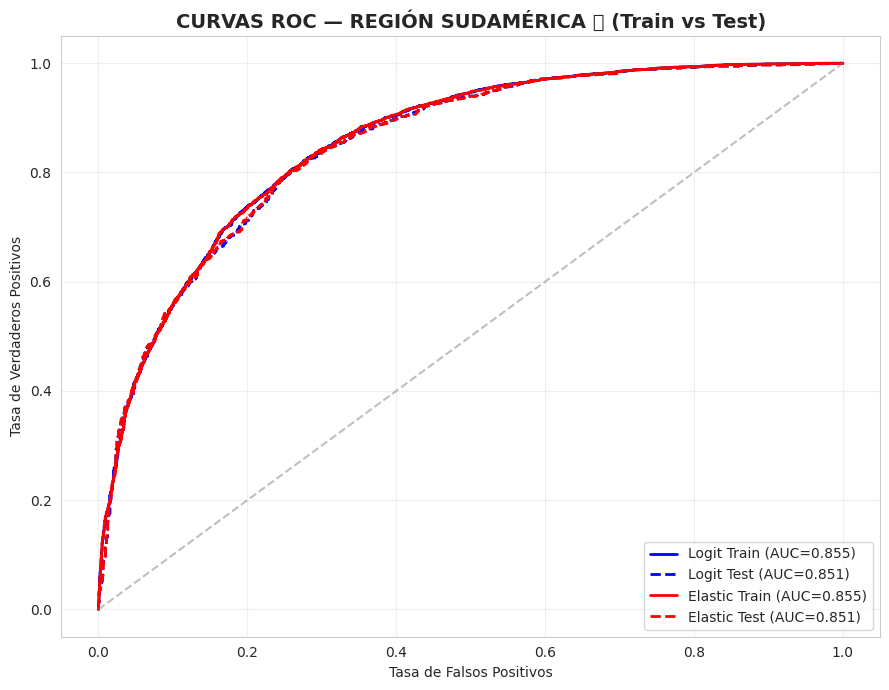

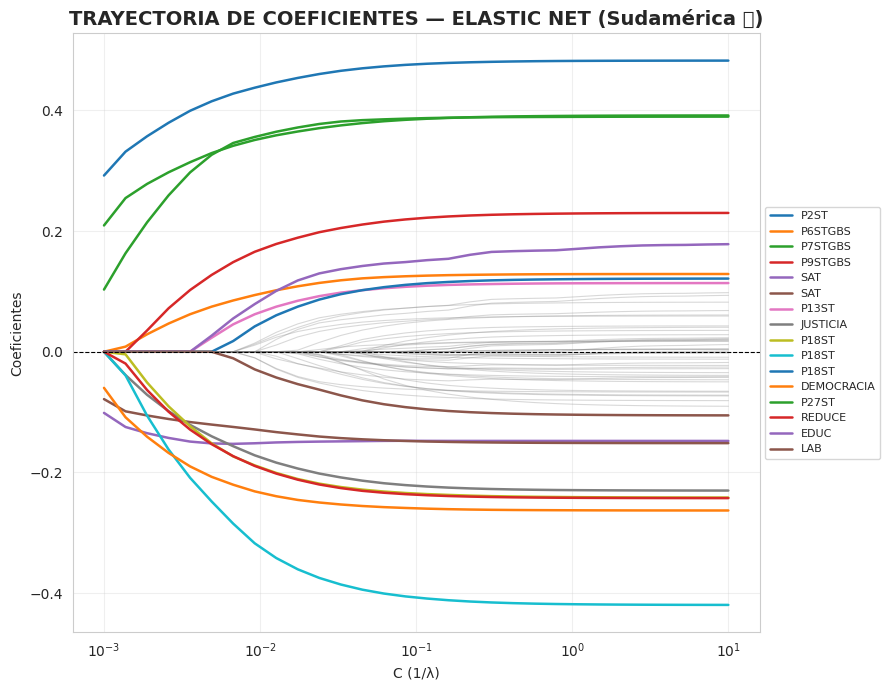

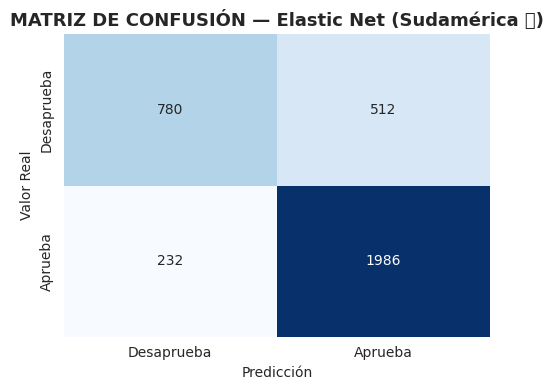

In [20]:
# =============================================================================
# CELDA — SUDAMÉRICA 🌎
# ROC Train/Test + Trayectoria ElasticNet + Matriz de Confusión
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

sns.set_style("whitegrid")

print("FILTRANDO SUDAMÉRICA 🌎...")

# ============================================================================
# 1) PREPARACIÓN DE DATOS - Sudamérica
# ============================================================================

y_col = 'P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente_bin'
df_sud = df.copy()

if y_col not in df_sud.columns:
    raise ValueError("No se encontró la variable dependiente para Sudamérica.")

y = df_sud[y_col]
X = df_sud.drop(columns=[y_col, 'IDENPA: País'], errors='ignore')

special_codes = [97, 98, 99]
X = X.replace(special_codes, np.nan)
y = y.replace(special_codes, np.nan)

mask = ~y.isna()
X, y = X[mask], y[mask].astype(int)

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

# División
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.3, random_state=42, stratify=y
)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"📊 Observaciones Sudamérica: {len(X_imputed)}")

# ============================================================================
# 2) ENTRENAR MODELOS LOGIT Y ELASTIC NET
# ============================================================================

logit_model = LogisticRegression(
    penalty=None, solver='lbfgs', random_state=42, max_iter=1000
)

elastic_model = LogisticRegression(
    penalty='elasticnet', solver='saga', C=0.1, l1_ratio=0.7,
    random_state=42, max_iter=3000
)

logit_model.fit(X_train_scaled, y_train)
elastic_model.fit(X_train_scaled, y_train)

# Predicciones Train/Test
y_train_pred_logit = logit_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_logit  = logit_model.predict_proba(X_test_scaled)[:, 1]

y_train_pred_elastic = elastic_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_elastic  = elastic_model.predict_proba(X_test_scaled)[:, 1]

# AUCs
auc_logit_train   = roc_auc_score(y_train, y_train_pred_logit)
auc_logit_test    = roc_auc_score(y_test,  y_test_pred_logit)
auc_el_train      = roc_auc_score(y_train, y_train_pred_elastic)
auc_el_test       = roc_auc_score(y_test,  y_test_pred_elastic)

# ============================================================================
# 3) CURVAS ROC - Sudamérica
# ============================================================================

fig, ax = plt.subplots(figsize=(9, 7))

# Logit
fpr_lt, tpr_lt, _ = roc_curve(y_train, y_train_pred_logit)
fpr_le, tpr_le, _ = roc_curve(y_test,  y_test_pred_logit)
ax.plot(fpr_lt, tpr_lt, color='blue', lw=2, label=f"Logit Train (AUC={auc_logit_train:.3f})")
ax.plot(fpr_le, tpr_le, color='blue', lw=2, linestyle="--", label=f"Logit Test (AUC={auc_logit_test:.3f})")

# Elastic Net
fpr_et, tpr_et, _ = roc_curve(y_train, y_train_pred_elastic)
fpr_ee, tpr_ee, _ = roc_curve(y_test,  y_test_pred_elastic)
ax.plot(fpr_et, tpr_et, color='red', lw=2, label=f"Elastic Train (AUC={auc_el_train:.3f})")
ax.plot(fpr_ee, tpr_ee, color='red', lw=2, linestyle="--", label=f"Elastic Test (AUC={auc_el_test:.3f})")

# Diagonal
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)

ax.set_title("CURVAS ROC — REGIÓN SUDAMÉRICA 🌎 (Train vs Test)", fontsize=14, fontweight="bold")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 4) TRAYECTORIA DE COEFICIENTES - Elastic Net Sudamérica
# ============================================================================

C_values = np.logspace(-3, 1, 30)
coefs_el = []

for C in C_values:
    m = LogisticRegression(
        penalty='elasticnet', solver='saga',
        C=C, l1_ratio=0.7, random_state=42, max_iter=3000
    )
    m.fit(X_train_scaled, y_train)
    coefs_el.append(m.coef_[0])

coefs_el_df = pd.DataFrame(coefs_el, columns=X_train.columns, index=C_values)

def extraer_codigo(v):
    v = str(v)
    for sep in [":", "-", "–", ".", "_"]:
        if sep in v:
            v = v.split(sep)[0]
    return v.strip()

plt.figure(figsize=(9, 7))
plt.title("TRAYECTORIA DE COEFICIENTES — ELASTIC NET (Sudamérica 🌎)", fontsize=14, fontweight="bold")
plt.xscale("log")
plt.xlabel("C (1/λ)")
plt.ylabel("Coeficientes")

for col in coefs_el_df.columns:
    serie = coefs_el_df[col]
    if np.max(np.abs(serie)) > 0.1:
        plt.plot(serie.index, serie.values, lw=1.8, label=extraer_codigo(col))
    else:
        plt.plot(serie.index, serie.values, lw=0.8, color="gray", alpha=0.3)

plt.axhline(0, color="black", lw=0.8, linestyle="--")
plt.grid(alpha=0.3)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

# ============================================================================
# 5) MATRIZ DE CONFUSIÓN — Elastic Net Sudamérica
# ============================================================================

y_pred_bin = (y_test_pred_elastic >= 0.5).astype(int)
cm_sud = confusion_matrix(y_test, y_pred_bin)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_sud, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Desaprueba", "Aprueba"],
            yticklabels=["Desaprueba", "Aprueba"])
plt.title("MATRIZ DE CONFUSIÓN — Elastic Net (Sudamérica 🌎)", fontsize=13, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()


PREPARANDO DATOS...
Datos: (11700, 59)
Aprobación: 63.2%

ENTRENANDO MODELOS...
✅ Logit Simple  - AUC: 0.853
✅ Elastic Net   - AUC: 0.854

RESUMEN FINAL

📊 COMPARACIÓN DE MODELOS:
   • Logit Simple  - AUC: 0.853
   • Elastic Net   - AUC: 0.854

🎯 Accuracy:
   • Logit Simple  : 0.797
   • Elastic Net   : 0.795

⚙️  Error Cuadrático Medio (MSE):
   • Logit Simple  : 0.1455
   • Elastic Net   : 0.1452

📊 Varianza de las Predicciones:
   • Logit Simple  : 0.08885
   • Elastic Net   : 0.08693
   • Diferencia    : 0.00191


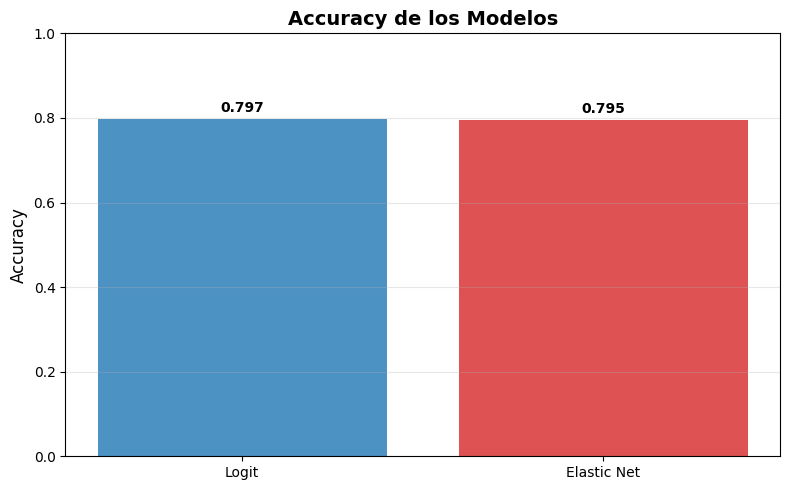

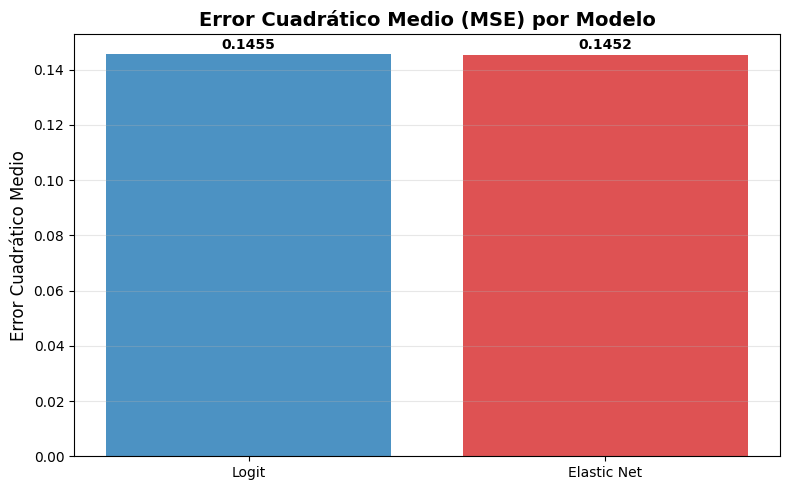

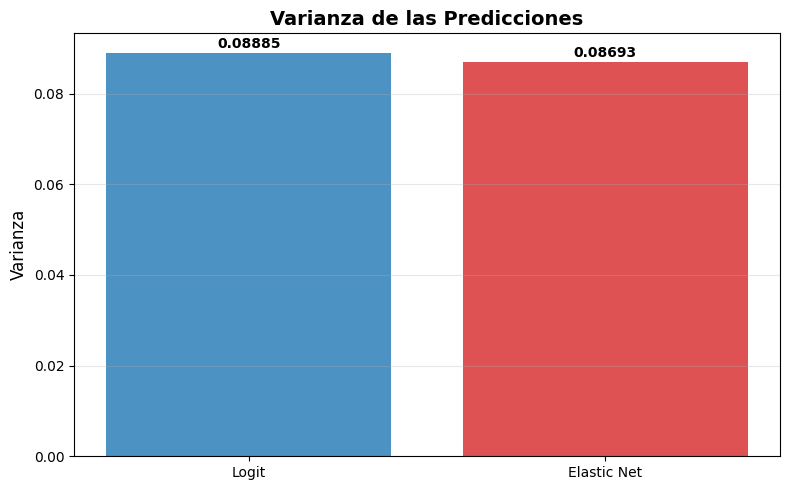


✅ ANÁLISIS COMPLETADO CON ÉXITO ✅


In [21]:
# =============================================================================
# REGRESIÓN LOGÍSTICA - LOGIT vs ELASTIC NET (COMPARATIVO COMPLETO)
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, mean_squared_error, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

plt.style.use('default')
np.random.seed(42)

# =============================================================================
# 1. PREPARACIÓN DE DATOS
# =============================================================================
print("PREPARANDO DATOS...")

y_col = 'P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente_bin'
y = df[y_col]
X = df.drop(columns=[y_col])

# Limpieza de valores especiales
special_codes = [97, 98, 99]
X = X.replace(special_codes, np.nan)
y = y.replace(special_codes, np.nan)
mask = ~y.isna()
X = X[mask]
y = y[mask].astype(int)

# Imputación
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

print(f"Datos: {X_imputed.shape}")
print(f"Aprobación: {y.mean()*100:.1f}%")

# =============================================================================
# 2. DIVISIÓN Y ESCALADO
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================================================================
# 3. ENTRENAMIENTO DE MODELOS
# =============================================================================
print("\nENTRENANDO MODELOS...")

logit_model = LogisticRegression(
    penalty=None, solver='lbfgs', random_state=42, max_iter=1000
)
elastic_model = LogisticRegression(
    penalty='elasticnet', solver='saga', C=0.1, l1_ratio=0.7,
    random_state=42, max_iter=3000
)

logit_model.fit(X_train_scaled, y_train)
elastic_model.fit(X_train_scaled, y_train)

y_pred_logit = logit_model.predict_proba(X_test_scaled)[:, 1]
y_pred_elastic = elastic_model.predict_proba(X_test_scaled)[:, 1]

auc_logit = roc_auc_score(y_test, y_pred_logit)
auc_elastic = roc_auc_score(y_test, y_pred_elastic)

print(f"✅ Logit Simple  - AUC: {auc_logit:.3f}")
print(f"✅ Elastic Net   - AUC: {auc_elastic:.3f}")


# =============================================================================
# 4. MÉTRICAS Y GRÁFICOS
# =============================================================================
print("\n" + "="*60)
print("RESUMEN FINAL")
print("="*60)
print(f"\n📊 COMPARACIÓN DE MODELOS:")
print(f"   • Logit Simple  - AUC: {auc_logit:.3f}")
print(f"   • Elastic Net   - AUC: {auc_elastic:.3f}")

# --- Accuracy ---
y_pred_logit_class = (y_pred_logit >= 0.5).astype(int)
y_pred_elastic_class = (y_pred_elastic >= 0.5).astype(int)
acc_logit = accuracy_score(y_test, y_pred_logit_class)
acc_elastic = accuracy_score(y_test, y_pred_elastic_class)

# --- MSE ---
mse_logit = mean_squared_error(y_test, y_pred_logit)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)

# --- Varianza ---
var_logit = np.var(y_pred_logit)
var_elastic = np.var(y_pred_elastic)

print(f"\n🎯 Accuracy:")
print(f"   • Logit Simple  : {acc_logit:.3f}")
print(f"   • Elastic Net   : {acc_elastic:.3f}")

print(f"\n⚙️  Error Cuadrático Medio (MSE):")
print(f"   • Logit Simple  : {mse_logit:.4f}")
print(f"   • Elastic Net   : {mse_elastic:.4f}")

print(f"\n📊 Varianza de las Predicciones:")
print(f"   • Logit Simple  : {var_logit:.5f}")
print(f"   • Elastic Net   : {var_elastic:.5f}")
print(f"   • Diferencia    : {(var_logit - var_elastic):.5f}")

# --- Gráfico Accuracy ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Logit', 'Elastic Net'], [acc_logit, acc_elastic], color=['#1f77b4', '#d62728'], alpha=0.8)
ax.set_title("Accuracy de los Modelos", fontweight='bold', fontsize=14)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([acc_logit, acc_elastic]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Gráfico MSE ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Logit', 'Elastic Net'], [mse_logit, mse_elastic], color=['#1f77b4', '#d62728'], alpha=0.8)
ax.set_title("Error Cuadrático Medio (MSE) por Modelo", fontweight='bold', fontsize=14)
ax.set_ylabel("Error Cuadrático Medio", fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([mse_logit, mse_elastic]):
    ax.text(i, v + 0.001, f"{v:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Gráfico Varianza ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Logit', 'Elastic Net'], [var_logit, var_elastic], color=['#1f77b4', '#d62728'], alpha=0.8)
ax.set_title("Varianza de las Predicciones", fontweight='bold', fontsize=14)
ax.set_ylabel("Varianza", fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([var_logit, var_elastic]):
    ax.text(i, v + 0.0005, f"{v:.5f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ ANÁLISIS COMPLETADO CON ÉXITO ✅")


FILTRANDO ARGENTINA 🇦🇷...
📊 Observaciones Argentina: 1194
Datos Argentina: (1194, 58)
Aprobación promedio: 54.4%

ENTRENANDO MODELOS PARA ARGENTINA...
✅ Logit Simple  - AUC: 0.850
✅ Elastic Net   - AUC: 0.859

RESUMEN FINAL - ARGENTINA 🇦🇷

📊 COMPARACIÓN DE MODELOS:
   • Logit Simple  - AUC: 0.850
   • Elastic Net   - AUC: 0.859

🎯 Accuracy:
   • Logit Simple  : 0.783
   • Elastic Net   : 0.791

⚙️  Error Cuadrático Medio (MSE):
   • Logit Simple  : 0.1549
   • Elastic Net   : 0.1479

📊 Varianza de las Predicciones:
   • Logit Simple  : 0.12830
   • Elastic Net   : 0.11008
   • Diferencia    : 0.01822


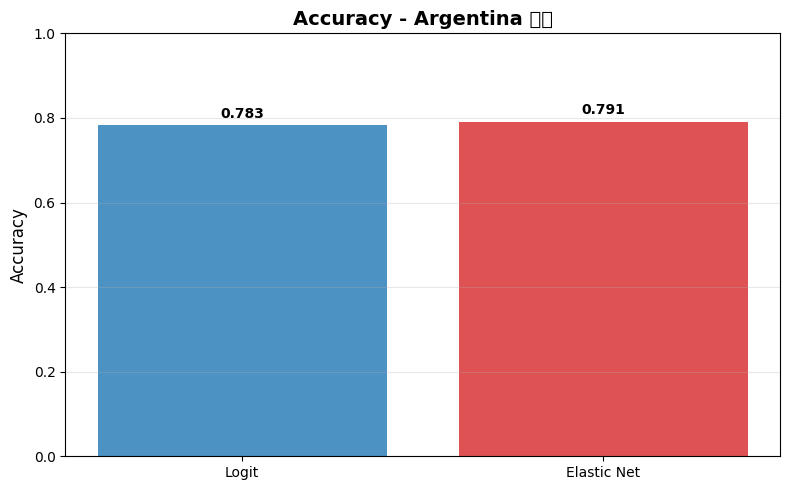

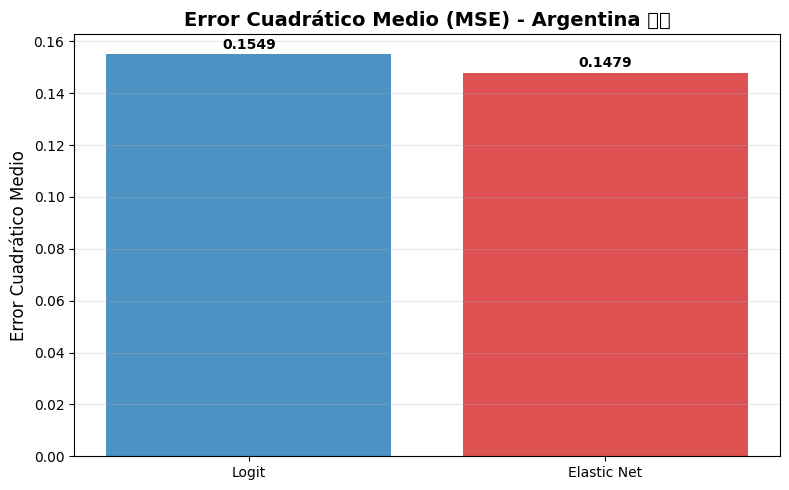

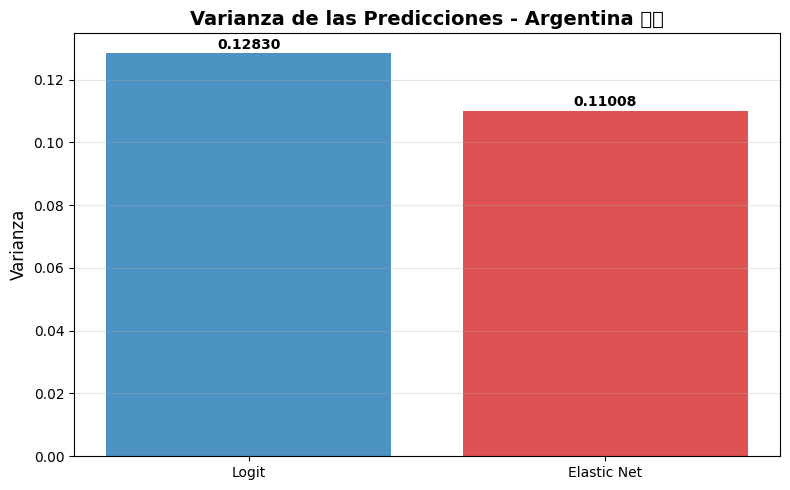


✅ ANÁLISIS COMPLETADO CON ÉXITO PARA ARGENTINA 🇦🇷 ✅


In [22]:
# =============================================================================
# REGRESIÓN LOGÍSTICA - LOGIT vs ELASTIC NET (ARGENTINA 🇦🇷)
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, mean_squared_error, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

plt.style.use('default')
np.random.seed(42)

# =============================================================================
# 1. PREPARACIÓN DE DATOS
# =============================================================================
print("FILTRANDO ARGENTINA 🇦🇷...")

df_arg = df[df['IDENPA: País'] == 32].copy()
print(f"📊 Observaciones Argentina: {df_arg.shape[0]}")

y_col = 'P15STGBS: Aprobación de la gestión del gobierno que encabeza el Presidente_bin'
if y_col not in df_arg.columns:
    raise ValueError(f"No se encontró la variable dependiente: {y_col}")

y = df_arg[y_col]
X = df_arg.drop(columns=[y_col, 'IDENPA: País'], errors='ignore')

special_codes = [97, 98, 99]
X = X.replace(special_codes, np.nan)
y = y.replace(special_codes, np.nan)
mask = ~y.isna()
X = X[mask]
y = y[mask].astype(int)

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

print(f"Datos Argentina: {X_imputed.shape}")
print(f"Aprobación promedio: {y.mean()*100:.1f}%")

# =============================================================================
# 2. DIVISIÓN Y ESCALADO
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================================================================
# 3. ENTRENAMIENTO DE MODELOS
# =============================================================================
print("\nENTRENANDO MODELOS PARA ARGENTINA...")

logit_model = LogisticRegression(penalty=None, solver='lbfgs', random_state=42, max_iter=1000)
elastic_model = LogisticRegression(
    penalty='elasticnet', solver='saga', C=0.1, l1_ratio=0.7,
    random_state=42, max_iter=3000
)

logit_model.fit(X_train_scaled, y_train)
elastic_model.fit(X_train_scaled, y_train)

y_pred_logit = logit_model.predict_proba(X_test_scaled)[:, 1]
y_pred_elastic = elastic_model.predict_proba(X_test_scaled)[:, 1]

auc_logit = roc_auc_score(y_test, y_pred_logit)
auc_elastic = roc_auc_score(y_test, y_pred_elastic)

print(f"✅ Logit Simple  - AUC: {auc_logit:.3f}")
print(f"✅ Elastic Net   - AUC: {auc_elastic:.3f}")


# =============================================================================
# 4. MÉTRICAS Y GRÁFICOS
# =============================================================================
print("\n" + "="*60)
print("RESUMEN FINAL - ARGENTINA 🇦🇷")
print("="*60)
print(f"\n📊 COMPARACIÓN DE MODELOS:")
print(f"   • Logit Simple  - AUC: {auc_logit:.3f}")
print(f"   • Elastic Net   - AUC: {auc_elastic:.3f}")

y_pred_logit_class = (y_pred_logit >= 0.5).astype(int)
y_pred_elastic_class = (y_pred_elastic >= 0.5).astype(int)
acc_logit = accuracy_score(y_test, y_pred_logit_class)
acc_elastic = accuracy_score(y_test, y_pred_elastic_class)

mse_logit = mean_squared_error(y_test, y_pred_logit)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
var_logit = np.var(y_pred_logit)
var_elastic = np.var(y_pred_elastic)

print(f"\n🎯 Accuracy:")
print(f"   • Logit Simple  : {acc_logit:.3f}")
print(f"   • Elastic Net   : {acc_elastic:.3f}")
print(f"\n⚙️  Error Cuadrático Medio (MSE):")
print(f"   • Logit Simple  : {mse_logit:.4f}")
print(f"   • Elastic Net   : {mse_elastic:.4f}")
print(f"\n📊 Varianza de las Predicciones:")
print(f"   • Logit Simple  : {var_logit:.5f}")
print(f"   • Elastic Net   : {var_elastic:.5f}")
print(f"   • Diferencia    : {(var_logit - var_elastic):.5f}")

# --- Gráfico Accuracy ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Logit', 'Elastic Net'], [acc_logit, acc_elastic], color=['#1f77b4', '#d62728'], alpha=0.8)
ax.set_title("Accuracy - Argentina 🇦🇷", fontweight='bold', fontsize=14)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([acc_logit, acc_elastic]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Gráfico MSE ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Logit', 'Elastic Net'], [mse_logit, mse_elastic], color=['#1f77b4', '#d62728'], alpha=0.8)
ax.set_title("Error Cuadrático Medio (MSE) - Argentina 🇦🇷", fontweight='bold', fontsize=14)
ax.set_ylabel("Error Cuadrático Medio", fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([mse_logit, mse_elastic]):
    ax.text(i, v + 0.001, f"{v:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Gráfico Varianza ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Logit', 'Elastic Net'], [var_logit, var_elastic], color=['#1f77b4', '#d62728'], alpha=0.8)
ax.set_title("Varianza de las Predicciones - Argentina 🇦🇷", fontweight='bold', fontsize=14)
ax.set_ylabel("Varianza", fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([var_logit, var_elastic]):
    ax.text(i, v + 0.0005, f"{v:.5f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ ANÁLISIS COMPLETADO CON ÉXITO PARA ARGENTINA 🇦🇷 ✅")


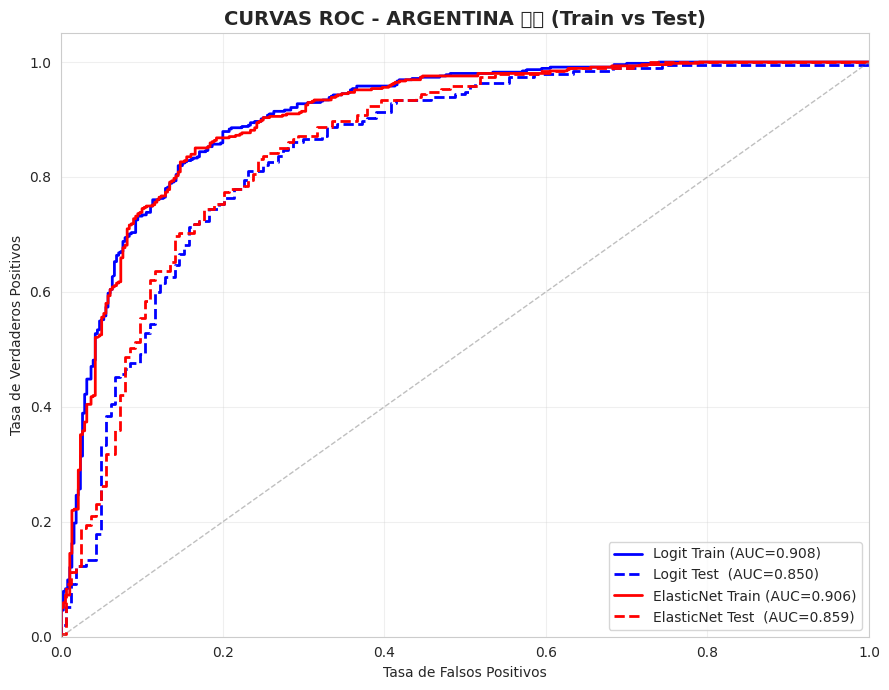

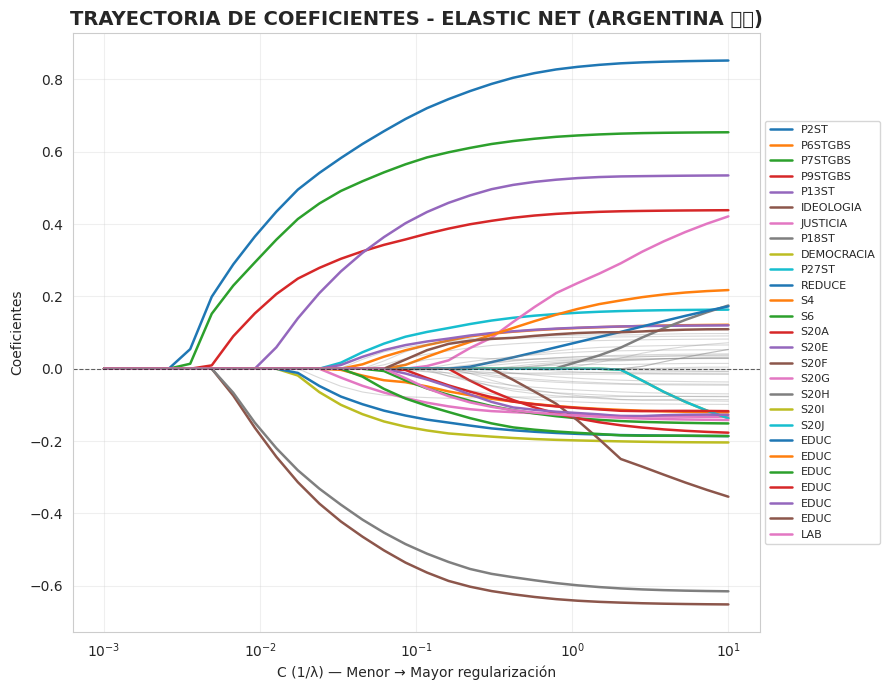

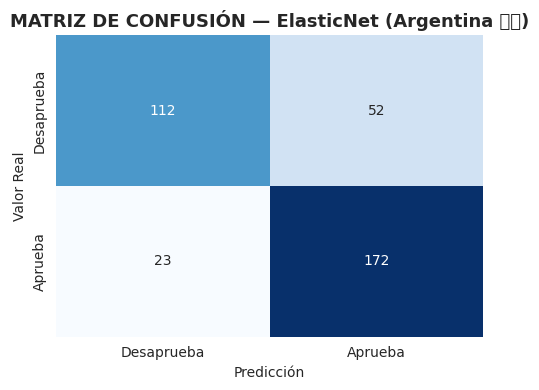

In [19]:
# =============================================================================
# CELDA 17 — ARGENTINA 🇦🇷
# ROC Train/Test + Trayectoria ElasticNet + Matriz de Confusión
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

sns.set_style("whitegrid")

# =============================================================================
# 1) CURVAS ROC — LOGIT (Train/Test) + ELASTICNET (Train/Test)
# =============================================================================

# --- Predicciones ---
y_train_pred_logit   = logit_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_logit    = logit_model.predict_proba(X_test_scaled)[:, 1]

y_train_pred_elastic = elastic_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_elastic  = elastic_model.predict_proba(X_test_scaled)[:, 1]

# --- AUC ---
auc_logit_train   = roc_auc_score(y_train, y_train_pred_logit)
auc_logit_test    = roc_auc_score(y_test,  y_test_pred_logit)
auc_el_train      = roc_auc_score(y_train, y_train_pred_elastic)
auc_el_test       = roc_auc_score(y_test,  y_test_pred_elastic)

# --- Trazar ---
fig, ax = plt.subplots(figsize=(9, 7))

# Logit
fpr_l_train, tpr_l_train, _ = roc_curve(y_train, y_train_pred_logit)
fpr_l_test,  tpr_l_test,  _ = roc_curve(y_test,  y_test_pred_logit)
ax.plot(fpr_l_train, tpr_l_train, color='blue', lw=2, linestyle='-',
        label=f"Logit Train (AUC={auc_logit_train:.3f})")
ax.plot(fpr_l_test,  tpr_l_test,  color='blue', lw=2, linestyle='--',
        label=f"Logit Test  (AUC={auc_logit_test:.3f})")

# Elastic Net
fpr_e_train, tpr_e_train, _ = roc_curve(y_train, y_train_pred_elastic)
fpr_e_test,  tpr_e_test,  _ = roc_curve(y_test,  y_test_pred_elastic)
ax.plot(fpr_e_train, tpr_e_train, color='red', lw=2, linestyle='-',
        label=f"ElasticNet Train (AUC={auc_el_train:.3f})")
ax.plot(fpr_e_test,  tpr_e_test,  color='red', lw=2, linestyle='--',
        label=f"ElasticNet Test  (AUC={auc_el_test:.3f})")

# Diagonal
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.5)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("CURVAS ROC - ARGENTINA 🇦🇷 (Train vs Test)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================================
# 2) TRAYECTORIA DE COEFICIENTES — ELASTIC NET (ARGENTINA) — AJUSTE DE TAMAÑO
# ============================================================================

C_values = np.logspace(-3, 1, 30)
coefs_el = []

for C in C_values:
    m = LogisticRegression(
        penalty='elasticnet', solver='saga',
        C=C, l1_ratio=0.7, random_state=42, max_iter=3000
    )
    m.fit(X_train_scaled, y_train)
    coefs_el.append(m.coef_[0])

coefs_el_df = pd.DataFrame(coefs_el, columns=X_train.columns, index=C_values)

def extraer_codigo(v):
    v = str(v)
    for sep in [':', '-', '–', '.', '_']:
        if sep in v:
            v = v.split(sep)[0]
    return v.strip()

# 👉 MISMO TAMAÑO QUE EL ROC
plt.figure(figsize=(9, 7))

plt.title("TRAYECTORIA DE COEFICIENTES - ELASTIC NET (ARGENTINA 🇦🇷)",
          fontsize=14, fontweight="bold")

plt.xscale("log")
plt.xlabel("C (1/λ) — Menor → Mayor regularización")
plt.ylabel("Coeficientes")

for col in coefs_el_df.columns:
    serie = coefs_el_df[col]
    if np.max(np.abs(serie)) > 0.1:
        plt.plot(serie.index, serie.values, lw=1.8, label=extraer_codigo(col))
    else:
        plt.plot(serie.index, serie.values, lw=0.8, alpha=0.3, color="gray")

plt.axhline(0, color="black", lw=0.8, linestyle="--", alpha=0.6)
plt.grid(alpha=0.3)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()
plt.show()



# =============================================================================
# 3) MATRIZ DE CONFUSIÓN — ELASTIC NET (ARGENTINA 🇦🇷)
# =============================================================================

y_pred_el_bin = (y_test_pred_elastic >= 0.5).astype(int)
cm_arg = confusion_matrix(y_test, y_pred_el_bin)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_arg, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Desaprueba", "Aprueba"],
            yticklabels=["Desaprueba", "Aprueba"])

plt.title("MATRIZ DE CONFUSIÓN — ElasticNet (Argentina 🇦🇷)", fontsize=13, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()


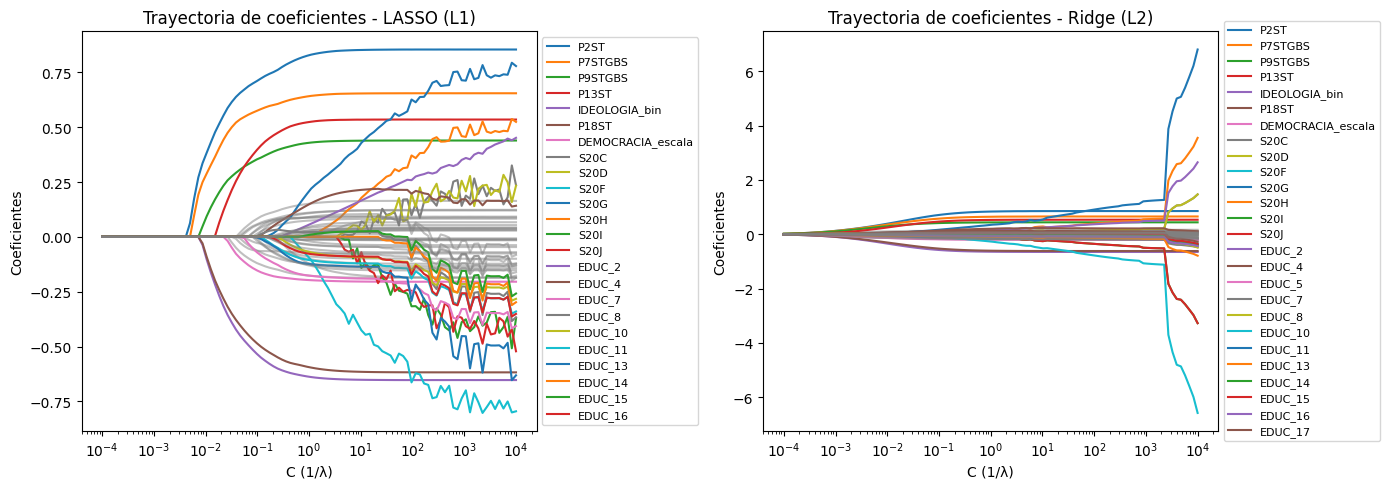

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
#Elastic net = L1 + L2
# Supongamos que ya tenés tus datos escalados
# X_train_scaled, y_train

# Definimos el rango de C (inverso de lambda)
C_values = np.logspace(-4, 4, 100)

# Listas para guardar coeficientes
coefs_lasso = []
coefs_ridge = []

# Entrenamos LASSO (L1)
for C in C_values:
    model_lasso = LogisticRegression(
        penalty='l1', solver='liblinear', C=C, max_iter=5000
    )
    model_lasso.fit(X_train_scaled, y_train)
    coefs_lasso.append(model_lasso.coef_[0])

# Entrenamos RIDGE (L2)
for C in C_values:
    model_ridge = LogisticRegression(
        penalty='l2', solver='lbfgs', C=C, max_iter=5000
    )
    model_ridge.fit(X_train_scaled, y_train)
    coefs_ridge.append(model_ridge.coef_[0])

# Convertimos a DataFrame
coefs_lasso = pd.DataFrame(coefs_lasso, columns=X_train.columns, index=C_values)
coefs_ridge = pd.DataFrame(coefs_ridge, columns=X_train.columns, index=C_values)

# --- GRAFICAMOS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Función para extraer solo el código
def extraer_codigo(nombre):
    return str(nombre).split(':')[0].split('–')[0].split('-')[0].split('.')[0].strip()

# LASSO
axes[0].set_title("Trayectoria de coeficientes - LASSO (L1)")
axes[0].set_xscale("log")
axes[0].set_xlabel("C (1/λ)")
axes[0].set_ylabel("Coeficientes")
for col in coefs_lasso.columns:
    # Verificar si los coeficientes están entre -0.2 y 0.2
    max_abs_val = np.max(np.abs(coefs_lasso[col]))
    if max_abs_val <= 0.2:
        axes[0].plot(coefs_lasso.index, coefs_lasso[col], color='gray', alpha=0.5)
    else:
        axes[0].plot(coefs_lasso.index, coefs_lasso[col], label=extraer_codigo(col))
axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

# RIDGE
axes[1].set_title("Trayectoria de coeficientes - Ridge (L2)")
axes[1].set_xscale("log")
axes[1].set_xlabel("C (1/λ)")
axes[1].set_ylabel("Coeficientes")
for col in coefs_ridge.columns:
    # Verificar si los coeficientes están entre -0.2 y 0.2
    max_abs_val = np.max(np.abs(coefs_ridge[col]))
    if max_abs_val <= 0.2:
        axes[1].plot(coefs_ridge.index, coefs_ridge[col], color='gray', alpha=0.5)
    else:
        axes[1].plot(coefs_ridge.index, coefs_ridge[col], label=extraer_codigo(col))
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()
plt.show()

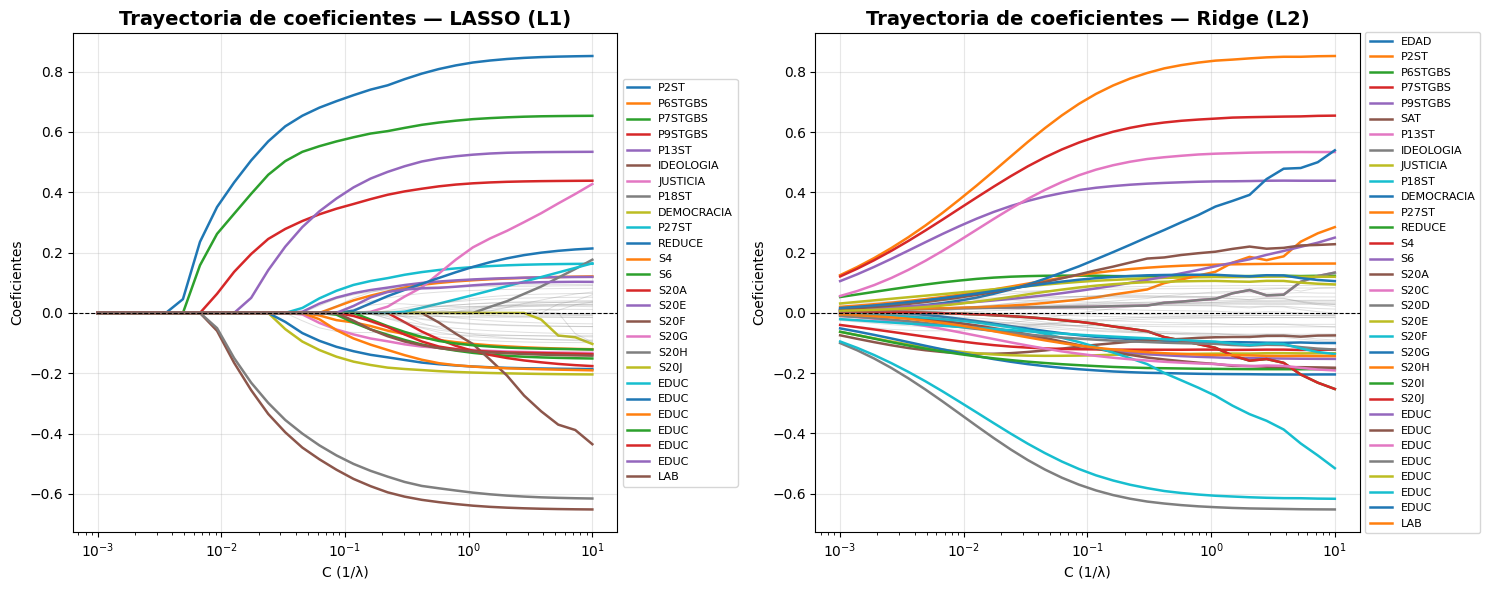

In [25]:
# ============================================================================
# TRAYECTORIA DE COEFICIENTES — LASSO (L1) vs RIDGE (L2)
# MISMO ESTILO QUE ANTES – DOS GRÁFICOS LADO A LADO
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Valores de C iguales al estilo anterior
C_values = np.logspace(-3, 1, 30)

# Listas para coeficientes
coefs_lasso = []
coefs_ridge = []

# LASSO (L1)
for C in C_values:
    m = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=C,
        max_iter=3000
    )
    m.fit(X_train_scaled, y_train)
    coefs_lasso.append(m.coef_[0])

# RIDGE (L2)
for C in C_values:
    m = LogisticRegression(
        penalty='l2',
        solver='lbfgs',
        C=C,
        max_iter=3000
    )
    m.fit(X_train_scaled, y_train)
    coefs_ridge.append(m.coef_[0])

# Convertir a DataFrames
coefs_lasso_df = pd.DataFrame(coefs_lasso, columns=X_train.columns, index=C_values)
coefs_ridge_df = pd.DataFrame(coefs_ridge, columns=X_train.columns, index=C_values)

def extraer_codigo(v):
    v = str(v)
    for sep in [":", "-", "–", ".", "_"]:
        if sep in v:
            v = v.split(sep)[0]
    return v.strip()

# =====================================================================
# GRAFICAR (2 columnas lado a lado)
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -------------------------
# GRÁFICO 1 — LASSO (L1)
# -------------------------
axes[0].set_title("Trayectoria de coeficientes — LASSO (L1)", fontsize=14, fontweight="bold")
axes[0].set_xscale("log")
axes[0].set_xlabel("C (1/λ)")
axes[0].set_ylabel("Coeficientes")

for col in coefs_lasso_df.columns:
    serie = coefs_lasso_df[col]
    if np.max(np.abs(serie)) > 0.1:        # Solo coloreamos las relevantes
        axes[0].plot(serie.index, serie.values, lw=1.8, label=extraer_codigo(col))
    else:
        axes[0].plot(serie.index, serie.values, lw=0.7, alpha=0.25, color="gray")

axes[0].axhline(0, color="black", lw=0.8, linestyle="--")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)

# -------------------------
# GRÁFICO 2 — RIDGE (L2)
# -------------------------
axes[1].set_title("Trayectoria de coeficientes — Ridge (L2)", fontsize=14, fontweight="bold")
axes[1].set_xscale("log")
axes[1].set_xlabel("C (1/λ)")
axes[1].set_ylabel("Coeficientes")

for col in coefs_ridge_df.columns:
    serie = coefs_ridge_df[col]
    if np.max(np.abs(serie)) > 0.1:
        axes[1].plot(serie.index, serie.values, lw=1.8, label=extraer_codigo(col))
    else:
        axes[1].plot(serie.index, serie.values, lw=0.7, alpha=0.25, color="gray")

axes[1].axhline(0, color="black", lw=0.8, linestyle="--")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout()
plt.show()
